!!!!!!!!!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.dates as mdates

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# XGBoost
from xgboost import XGBRegressor

# Prophet
from prophet import Prophet


c:\Users\Anion\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
df_energy  = pd.read_csv('C:/Users/Anion/Desktop/vkr/energy_dataset.csv')
df_weather  = pd.read_csv('C:/Users/Anion/Desktop/vkr/weather_features.csv')

df_energy.head()

# df_energy.columns.tolist()
# df_weather.columns.tolist()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


### Подготовка df_weather

### Дубликаты

In [3]:
print(f"Rows per city:")
print(df_weather.groupby("city_name").size())

print("\nDuplicates city:")
duplicates_by_city = df_weather.groupby("city_name")["dt_iso"].apply(
    lambda timestamps: timestamps.duplicated().sum()
)
print(duplicates_by_city)

Rows per city:
city_name
 Barcelona    35476
Bilbao        35951
Madrid        36267
Seville       35557
Valencia      35145
dtype: int64

Duplicates city:
city_name
 Barcelona     412
Bilbao         887
Madrid        1203
Seville        493
Valencia        81
Name: dt_iso, dtype: int64


In [4]:
# пример дублирующихся строк
madrid_data = df_weather[df_weather["city_name"] == "Madrid"].copy()
duplicate_example = madrid_data[madrid_data["dt_iso"].duplicated(keep=False)].sort_values("dt_iso").head(6)
print(duplicate_example)

                          dt_iso city_name    temp  temp_min  temp_max  \
39125  2015-06-15 21:00:00+02:00    Madrid  287.07    286.85    287.15   
39126  2015-06-15 21:00:00+02:00    Madrid  287.07    286.85    287.15   
39128  2015-06-15 23:00:00+02:00    Madrid  286.96    286.05    287.45   
39129  2015-06-15 23:00:00+02:00    Madrid  286.96    286.05    287.45   
40011  2015-07-22 17:00:00+02:00    Madrid  306.63    305.05    309.15   
40012  2015-07-22 17:00:00+02:00    Madrid  306.63    305.05    309.15   

       pressure  humidity  wind_speed  wind_deg  rain_1h  rain_3h  snow_3h  \
39125      1018        87           4       100      0.9      0.0      0.0   
39126      1018        87           4       100      0.9      0.0      0.0   
39128      1020        87           3       360      0.3      0.0      0.0   
39129      1020        87           3       360      0.3      0.0      0.0   
40011      1016        33           5       310      0.3      0.0      0.0   
40012      10

Из-за того, что weather_main и weather_description могут принимать несколько значений в одно и то же время- появляются дубликаты. Необходимо их убрать

In [5]:
df_weather_clean = (
    df_weather
    .sort_values(["city_name", "dt_iso"])
    .drop_duplicates(subset=["city_name", "dt_iso"], keep="first")
    .reset_index(drop=True)
)

In [6]:
# Удаление ненужных столбцов
cols_to_drop = [
    'temp_min', 'temp_max',      # оставляем только temp
    'rain_3h', 'snow_3h',         # редкие события
    'weather_id', 'weather_icon',  # дублируют weather_main
    'weather_main', 'weather_description'
]

df_weather_clean = df_weather_clean.drop(columns=cols_to_drop)

df_weather_clean.columns.tolist()

['dt_iso',
 'city_name',
 'temp',
 'pressure',
 'humidity',
 'wind_speed',
 'wind_deg',
 'rain_1h',
 'clouds_all']

### Анализ погоды по городам

анализируем погоду по каждому городу, как показатели коррелируют между собой, чтобы при возможности уменьшить количество входных данных (признаков)

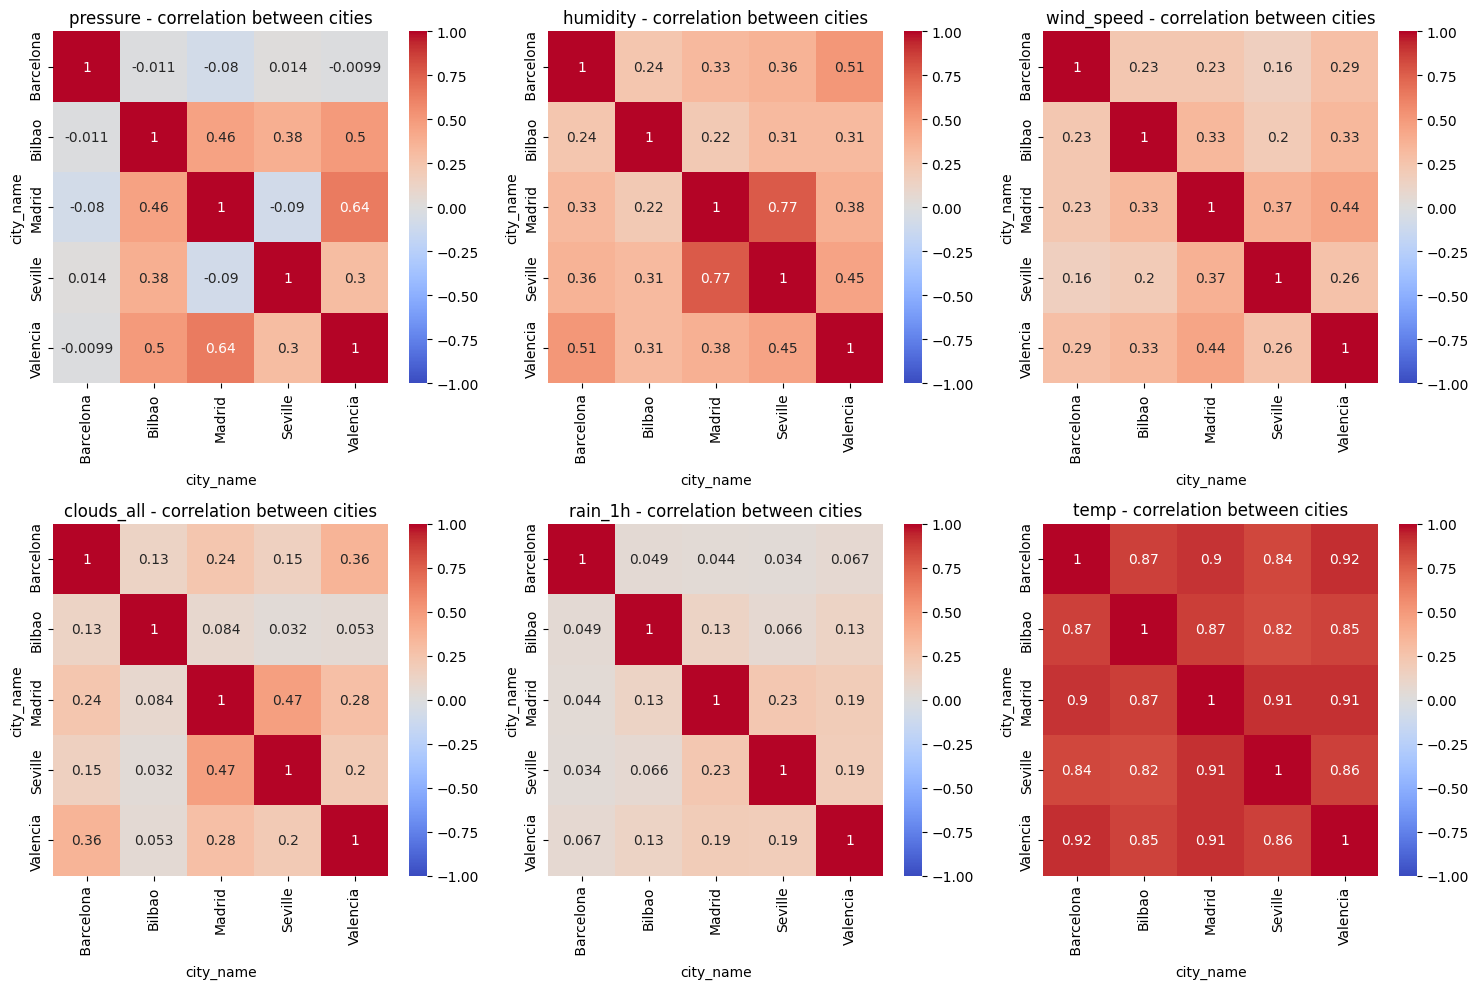

In [7]:
features = ['pressure', 'humidity', 'wind_speed', 'clouds_all', 'rain_1h', 'temp']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    pivot = df_weather_clean.pivot_table(
        index='dt_iso', 
        columns='city_name', 
        values=feat
    )
    corr = pivot.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[i], vmin=-1, vmax=1, center=0)
    axes[i].set_title(f'{feat} - correlation between cities')

# Убираем пустой график, если features меньше 6
if len(features) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

по карте видно, что погода по городам сильно взаимосвязана, её можно будет усреднить. у остальных же параметров корреляция существенно ниже, следовательно, лучше оставить их отдельно для каждого города

проверим, как каждый параметр по городам коррелирует с выработкой СЭС и ВЭС

In [8]:
df_merged = df_energy.merge(
    df_weather_clean,
    left_on='time',
    right_on='dt_iso',
    how='inner'
)

# Целевые переменные
targets = ['generation solar', 'generation wind onshore']

# Признаки
features = ['temp', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'clouds_all', 'rain_1h']
cities = df_weather_clean['city_name'].unique()

# Считаем корреляцию
results = []

for city in cities:
    city_data = df_merged[df_merged['city_name'] == city]
    for target in targets:
        for feat in features:
            corr = city_data[[feat, target]].corr().iloc[0, 1]
            results.append({
                'city': city,
                'target': target,
                'feature': feat,
                'correlation': round(corr, 4)
            })

# Таблица для solar
df_solar = pd.DataFrame([r for r in results if r['target'] == 'generation solar'])
df_solar = df_solar.pivot(index='feature', columns='city', values='correlation')
print("\n**SOLAR**")
print(df_solar.to_string())

# Таблица для wind
df_wind = pd.DataFrame([r for r in results if r['target'] == 'generation wind onshore'])
df_wind = df_wind.pivot(index='feature', columns='city', values='correlation')
print("\n**WIND**")
print(df_wind.to_string())


**SOLAR**
city         Barcelona  Bilbao  Madrid  Seville  Valencia
feature                                                  
clouds_all     -0.0409 -0.0141 -0.1084  -0.0786   -0.0111
humidity       -0.4130 -0.3648 -0.3846  -0.4553   -0.5049
pressure       -0.0069  0.0240  0.0163  -0.0190   -0.0051
rain_1h         0.0179 -0.0309 -0.0405  -0.0508   -0.0252
temp            0.3867  0.3990  0.3686   0.4161    0.4568
wind_deg       -0.1094  0.0855 -0.1124  -0.0158   -0.1077
wind_speed      0.2047  0.1670  0.0725   0.0951    0.1563

**WIND**
city         Barcelona  Bilbao  Madrid  Seville  Valencia
feature                                                  
clouds_all      0.0352  0.1333  0.1129   0.0670   -0.0071
humidity       -0.0548 -0.0384  0.0551   0.0140   -0.1643
pressure        0.0236 -0.0452 -0.0934  -0.0045   -0.0992
rain_1h         0.0266  0.2014  0.0693   0.0393    0.0355
temp           -0.1579 -0.1422 -0.1268  -0.1256   -0.1096
wind_deg        0.0010  0.1481  0.0755   0.1091    

для сокращения числа входных признаков Барселону и Севилью исключаем. Они демонстрируют наименьшую корреляцию с целевыми переменными (особенно с выработкой ветряной энергии)

In [9]:
df_weather_clean = df_weather_clean[
    ~df_weather_clean['city_name'].isin([' Barcelona', 'Seville'])
]

усредним же температуру и разделим параметры по оставшимся городам

In [10]:
# Формирование столбцов по городам
# Признаки по городам (низкая корреляция)
features_to_pivot = ['pressure', 'humidity', 'wind_speed', 'wind_deg', 'clouds_all', 'rain_1h']

# Разворачиваем по городам
df_weather_pivot = df_weather_clean.pivot_table(
    index='dt_iso', 
    columns='city_name', 
    values=features_to_pivot
)
# новых названия столбцов
df_weather_pivot.columns = [f'{feat}_{city}' for feat, city in df_weather_pivot.columns]
df_weather_pivot = df_weather_pivot.reset_index()

In [11]:
# температуру усредняем по городам
features_to_avg = ['temp']

df_weather_avg = df_weather_clean.groupby('dt_iso')[features_to_avg].mean().reset_index()

In [12]:
df_weather_final = df_weather_avg.merge(df_weather_pivot, on='dt_iso', validate='1:1')

print(f"Итоговое число признаков погоды: {len(df_weather_final.columns) - 1}")
print(df_weather_final.columns.tolist())

Итоговое число признаков погоды: 19
['dt_iso', 'temp', 'clouds_all_Bilbao', 'clouds_all_Madrid', 'clouds_all_Valencia', 'humidity_Bilbao', 'humidity_Madrid', 'humidity_Valencia', 'pressure_Bilbao', 'pressure_Madrid', 'pressure_Valencia', 'rain_1h_Bilbao', 'rain_1h_Madrid', 'rain_1h_Valencia', 'wind_deg_Bilbao', 'wind_deg_Madrid', 'wind_deg_Valencia', 'wind_speed_Bilbao', 'wind_speed_Madrid', 'wind_speed_Valencia']


### Удаление ненужных столбцов (df_energy)

In [13]:
# Список столбцов для удаления
columns_to_drop = [
    # Генерация не ВИЭ
    'generation fossil brown coal/lignite',
    'generation fossil coal-derived gas', 
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil oil',
    'generation fossil oil shale',
    'generation fossil peat',
    'generation geothermal',
    'generation hydro pumped storage aggregated',
    'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation marine',
    'generation nuclear',
    'generation other',
    'generation other renewable',
    'generation waste',
    'generation biomass',
    'generation wind offshore', # весь столбец- пустые данные
    
    # Прогнозы (модель должна учиться сама)
    'forecast solar day ahead',
    'forecast wind offshore eday ahead',
    'forecast wind onshore day ahead',
    'total load forecast',

    # Фактическая цена (не нужна, принимаем цену на сутки вперёд фиксированной)
    'price actual',

    # Спрос не нужен, мы оставили цену на РСВ, а она уже отражает спрос
    'total load actual'
]

# Удаление столбцов
df_energy = df_energy.drop(columns=[col for col in columns_to_drop if col in df_energy.columns])

df_energy.columns

Index(['time', 'generation solar', 'generation wind onshore',
       'price day ahead'],
      dtype='object')

## Формирование общего датасета

### Время

приводим к одному виду

In [14]:
df_energy['time'] = pd.to_datetime(df_energy['time'])
df_weather_final['dt_iso'] = pd.to_datetime(df_weather_final['dt_iso'])

C:\Users\Anion\AppData\Local\Temp\ipykernel_9940\179499467.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_energy['time'] = pd.to_datetime(df_energy['time'])
C:\Users\Anion\AppData\Local\Temp\ipykernel_9940\179499467.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_weather_final['dt_iso'] = pd.to_datetime(df_weather_final['dt_iso'])


### Объединение

объединяем два массива данных, получаем итоговый **df**

In [15]:
# Объединяем энергетические данные с погодными данными
df = df_energy.merge(
    df_weather_final,
    left_on="time",
    right_on="dt_iso",
    how="left",
    validate="1:1"  # проверяем, что нет лишних строк
)

# Удаляем дублирующуюся колонку dt_iso
df = df.drop(columns=["dt_iso"])

print(f"Финальный размер данных: {df.shape}")
print(f"Колонок: {len(df.columns)}")

df.head()

Финальный размер данных: (35064, 23)
Колонок: 23


,time,generation solar,generation wind onshore,price day ahead,temp,clouds_all_Bilbao,clouds_all_Madrid,clouds_all_Valencia,humidity_Bilbao,humidity_Madrid,...,pressure_Valencia,rain_1h_Bilbao,rain_1h_Madrid,rain_1h_Valencia,wind_deg_Bilbao,wind_deg_Madrid,wind_deg_Valencia,wind_speed_Bilbao,wind_speed_Madrid,wind_speed_Valencia
0,2015-01-01 00:00:00+01:00,49.0,6378.0,50.10,269.152437,0.0,0.0,0.0,97.0,63.0,...,1001.0,0.0,0.0,0.0,226.0,309.0,62.0,0.0,1.0,1.0
1,2015-01-01 01:00:00+01:00,50.0,5890.0,48.10,269.187833,0.0,0.0,0.0,97.0,63.0,...,1001.0,0.0,0.0,0.0,229.0,309.0,62.0,0.0,1.0,1.0
2,2015-01-01 02:00:00+01:00,50.0,5461.0,47.33,268.374562,0.0,0.0,0.0,97.0,64.0,...,1002.0,0.0,0.0,0.0,224.0,273.0,23.0,1.0,1.0,0.0
3,2015-01-01 03:00:00+01:00,50.0,5238.0,42.27,268.358448,0.0,0.0,0.0,97.0,64.0,...,1002.0,0.0,0.0,0.0,225.0,273.0,23.0,1.0,1.0,0.0
4,2015-01-01 04:00:00+01:00,42.0,4935.0,38.41,268.452500,0.0,0.0,0.0,97.0,64.0,...,1002.0,0.0,0.0,0.0,221.0,273.0,23.0,1.0,1.0,0.0


### Проверка Null

In [16]:
missing = df.isnull().sum()
print(missing[missing > 0])

generation solar           18
generation wind onshore    18
dtype: int64


In [17]:
df = df.dropna(subset=['generation solar', 'generation wind onshore'])

### Временные признаки

In [18]:
df['time'] = pd.to_datetime(df['time'], utc=True).dt.tz_convert(None)

df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month

## Анализ и подготовка данных

распределение данных:

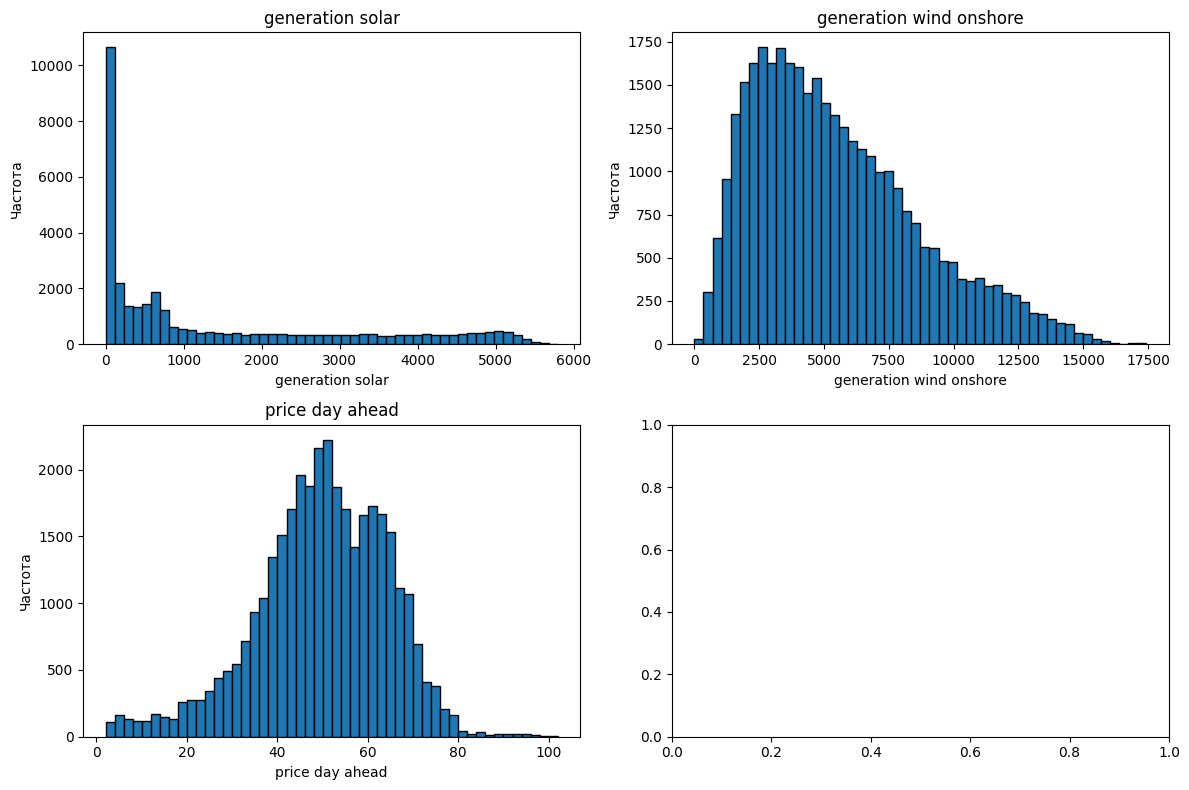

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

cols = ['generation solar', 'generation wind onshore', 'price day ahead']
for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=50, edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

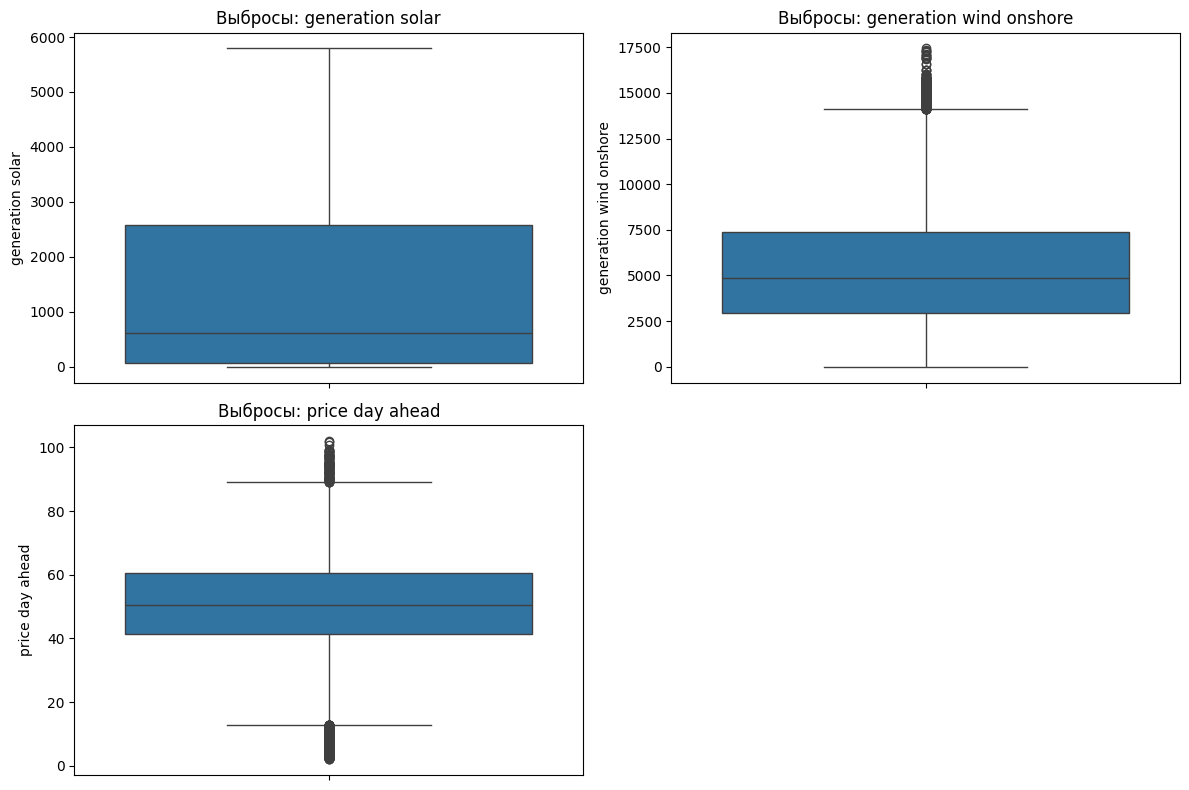

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(len(cols)):
    sns.boxplot(y=df[cols[i]], ax=axes[i])
    axes[i].set_title(f'Выбросы: {cols[i]}')

for i in range(len(cols), 4):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
for col in cols:
    mean = df[col].mean()
    std = df[col].std()
    outliers = df[(df[col] < mean - 3*std) | (df[col] > mean + 3*std)]
    print(f"{col}: {len(outliers)} выбросов ({len(outliers)/len(df)*100:.2f}%)")

generation solar: 0 выбросов (0.00%)
generation wind onshore: 113 выбросов (0.32%)
price day ahead: 329 выбросов (0.94%)


Выбросы только у ветра. Ветер может резко меняться, так что это вполне могут оказаться реальные данные. Выбросов <2%, сильно не должны повлиять

In [22]:
print(df[cols].describe())

       generation solar  generation wind onshore  price day ahead
count      35046.000000             35046.000000     35046.000000
mean        1432.665925              5464.479769        49.873031
std         1680.119887              3213.691587        14.617608
min            0.000000                 0.000000         2.060000
25%           71.000000              2933.000000        41.490000
50%          616.000000              4849.000000        50.520000
75%         2578.000000              7398.000000        60.530000
max         5792.000000             17436.000000       101.990000


### Анализ по месяцам и времени суток
Средняя генерация по часам

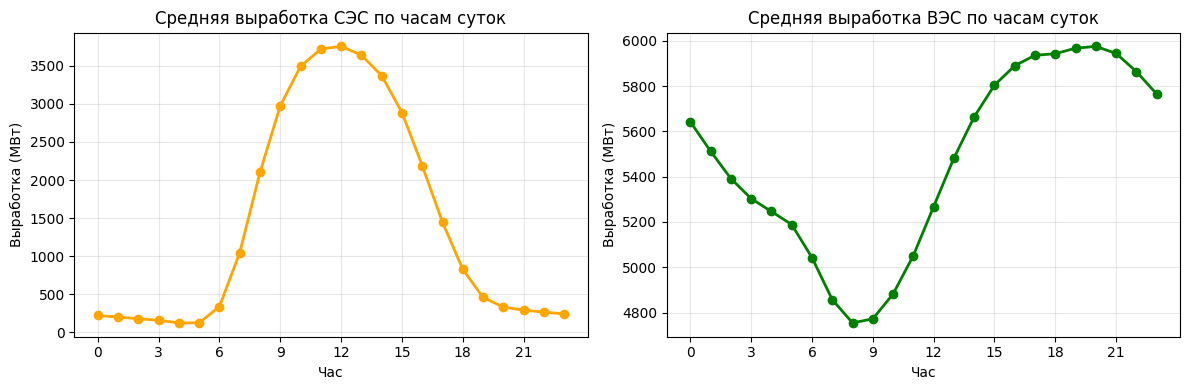

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Солнечная выработка
solar_by_hour = df.groupby('hour')['generation solar'].mean()
ax1.plot(solar_by_hour.index, solar_by_hour.values, marker='o', color='orange', linewidth=2)
ax1.set_title('Средняя выработка СЭС по часам суток', fontsize=12)
ax1.set_xlabel('Час')
ax1.set_ylabel('Выработка (МВт)')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, 24, 3))

# Ветряная выработка
wind_by_hour = df.groupby('hour')['generation wind onshore'].mean()
ax2.plot(wind_by_hour.index, wind_by_hour.values, marker='o', color='green', linewidth=2)
ax2.set_title('Средняя выработка ВЭС по часам суток', fontsize=12)
ax2.set_xlabel('Час')
ax2.set_ylabel('Выработка (МВт)')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

### Корреляция между признаками

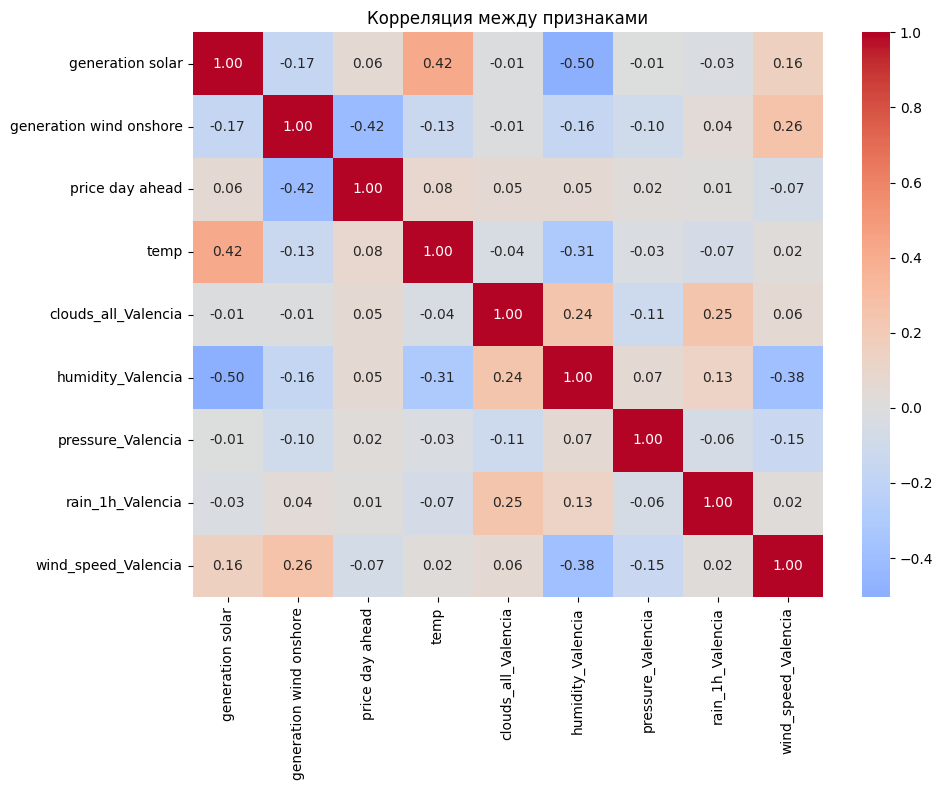

Корреляции с солнечной генерацией:
generation solar           1.000000
temp                       0.421457
wind_speed_Valencia        0.156299
price day ahead            0.058392
pressure_Valencia         -0.005138
clouds_all_Valencia       -0.011098
rain_1h_Valencia          -0.025238
generation wind onshore   -0.166901
humidity_Valencia         -0.504880
Name: generation solar, dtype: float64

Корреляции с ветровой генерацией:
generation wind onshore    1.000000
wind_speed_Valencia        0.263793
rain_1h_Valencia           0.035463
clouds_all_Valencia       -0.007147
pressure_Valencia         -0.099155
temp                      -0.131161
humidity_Valencia         -0.164333
generation solar          -0.166901
price day ahead           -0.424899
Name: generation wind onshore, dtype: float64


In [24]:
# необходимые признаки
numeric_cols = ['generation solar', 'generation wind onshore',
       'price day ahead', 'temp',
       'clouds_all_Valencia',
       'humidity_Valencia',
       'pressure_Valencia',
       'rain_1h_Valencia',
       'wind_speed_Valencia']

# корреляция
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

# Самые сильные корреляции с solar и wind
print("Корреляции с солнечной генерацией:")
print(corr_matrix['generation solar'].sort_values(ascending=False))

print("\nКорреляции с ветровой генерацией:")
print(corr_matrix['generation wind onshore'].sort_values(ascending=False))

Корреляция облачности и генерации днём на примере Валенсии

ожидаемо видим, что днём корреляция выше, чем в ночные часы

In [25]:
day_df = df[(df['hour'] >= 8) & (df['hour'] <= 18)]

# Корреляция для дневных часов
print("Корреляция в дневные часы (8-18):")
print(day_df[['generation solar', 'clouds_all_Valencia']].corr())

# Ночные часы
night_df = df[(df['hour'] < 8) | (df['hour'] > 18)]
print("\nКорреляция в ночные часы:")
print(night_df[['generation solar', 'clouds_all_Valencia']].corr())

Корреляция в дневные часы (8-18):
                     generation solar  clouds_all_Valencia
generation solar             1.000000            -0.113865
clouds_all_Valencia         -0.113865             1.000000

Корреляция в ночные часы:
                     generation solar  clouds_all_Valencia
generation solar             1.000000            -0.066126
clouds_all_Valencia         -0.066126             1.000000


### Связь выработки СЭС и температуры

In [26]:
df.columns

Index(['time', 'generation solar', 'generation wind onshore',
       'price day ahead', 'temp', 'clouds_all_Bilbao', 'clouds_all_Madrid',
       'clouds_all_Valencia', 'humidity_Bilbao', 'humidity_Madrid',
       'humidity_Valencia', 'pressure_Bilbao', 'pressure_Madrid',
       'pressure_Valencia', 'rain_1h_Bilbao', 'rain_1h_Madrid',
       'rain_1h_Valencia', 'wind_deg_Bilbao', 'wind_deg_Madrid',
       'wind_deg_Valencia', 'wind_speed_Bilbao', 'wind_speed_Madrid',
       'wind_speed_Valencia', 'hour', 'month'],
      dtype='object')

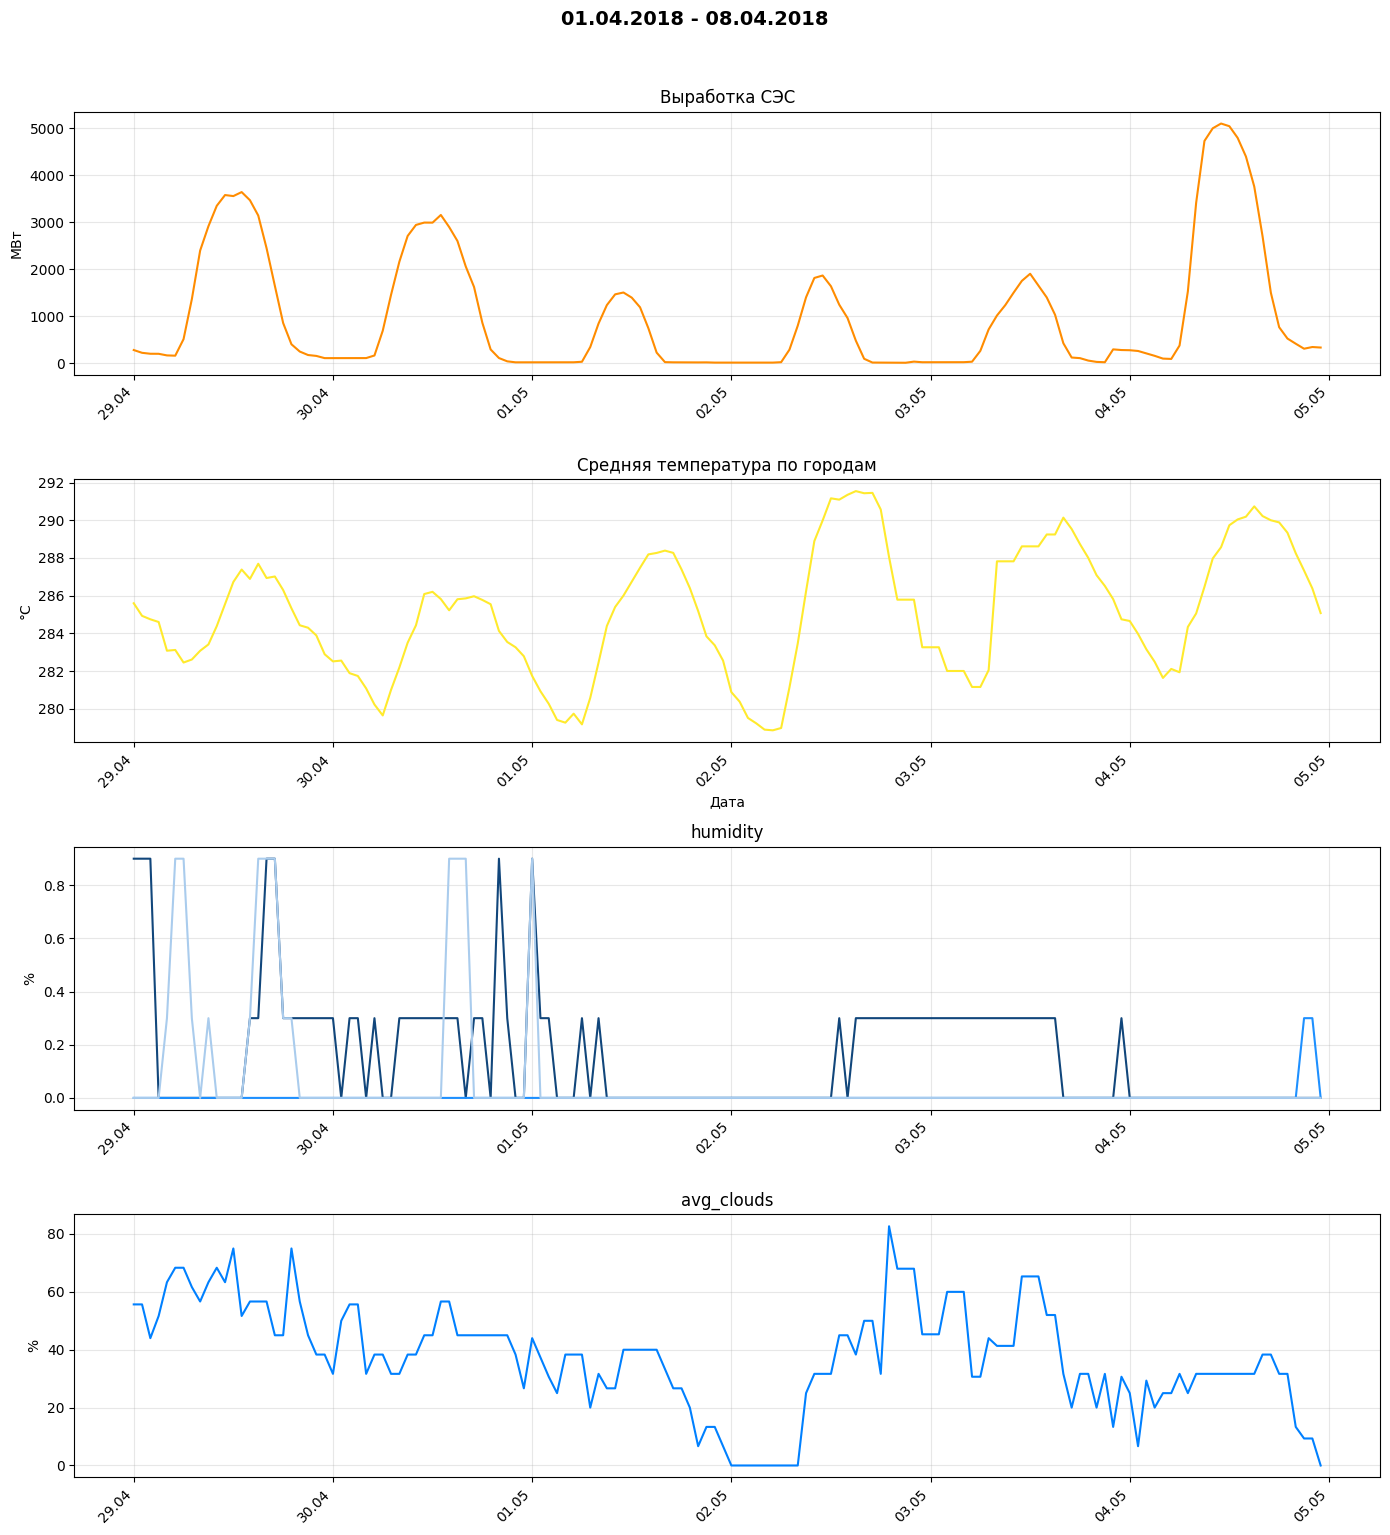

In [27]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 15))

clouds = pd.DataFrame({
    'time': df['time'].copy(),
    'avg_clouds': df[['clouds_all_Bilbao', 'clouds_all_Valencia', 'clouds_all_Madrid']].mean(axis=1)
})

start_date = '2018-04-29'
end_date = '2018-05-05'
mask = (df['time'] >= start_date) & (df['time'] < end_date)

# График 1: Солнечная генерация
ax1.plot(df.loc[mask, 'time'], df.loc[mask, 'generation solar'], 
         color='#FF8C00', linewidth=1.5)
ax1.set_title('Выработка СЭС', fontsize=12)
ax1.set_ylabel('МВт')
ax1.grid(True, alpha=0.3)

# График 2: Температура
ax2.plot(df.loc[mask, 'time'], df.loc[mask, 'temp'], 
         color="#FFEA2D", linewidth=1.5)
ax2.set_title('Средняя температура по городам', fontsize=12)
ax2.set_ylabel('°C')
ax2.grid(True, alpha=0.3)

# График 3
ax3.plot(df.loc[mask, 'time'], df.loc[mask, 'rain_1h_Bilbao'], 
         color="#11467B", linewidth=1.5)
ax3.set_title('clouds_all_Bilbao', fontsize=12)
ax3.set_ylabel('%')
ax3.grid(True, alpha=0.3)

ax3.plot(df.loc[mask, 'time'], df.loc[mask, 'rain_1h_Valencia'], 
         color='#1E90FF', linewidth=1.5)
ax3.set_title('clouds_all_Valencia', fontsize=12)
ax3.set_ylabel('%')
ax3.grid(True, alpha=0.3)

ax3.plot(df.loc[mask, 'time'], df.loc[mask, 'rain_1h_Madrid'], 
         color="#AACCED", linewidth=1.5)
ax3.set_title('humidity', fontsize=12)
ax3.set_ylabel('%')
ax3.grid(True, alpha=0.3)

# График 4
ax4.plot(clouds.loc[mask, 'time'], clouds.loc[mask, 'avg_clouds'], 
         color="#0080FF", linewidth=1.5)
ax4.set_title('avg_clouds', fontsize=12)
ax4.set_ylabel('%')
ax4.grid(True, alpha=0.3)

# Формат дат
for ax in [ax1, ax2, ax3, ax4]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2.set_xlabel('Дата')
plt.suptitle('01.04.2018 - 08.04.2018', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

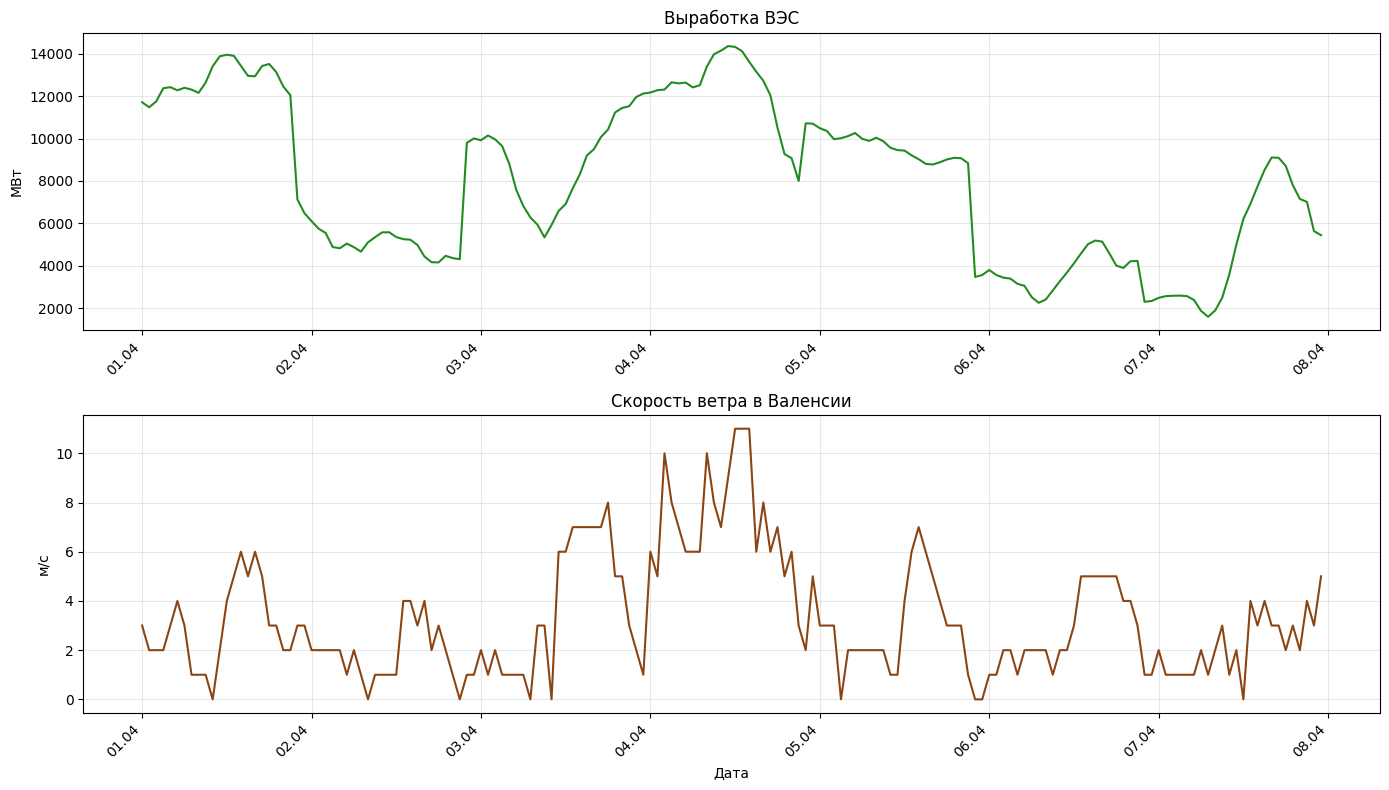

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

start_date = '2018-04-01'
end_date = '2018-04-08'
mask = (df['time'] >= start_date) & (df['time'] < end_date)

# График 1: Ветровая генерация
ax1.plot(df.loc[mask, 'time'], df.loc[mask, 'generation wind onshore'], 
         color='#228B22', linewidth=1.5)
ax1.set_title('Выработка ВЭС', fontsize=12)
ax1.set_ylabel('МВт')
ax1.grid(True, alpha=0.3)

# График 2: Скорость ветра в Валенсии
ax2.plot(df.loc[mask, 'time'], df.loc[mask, 'wind_speed_Valencia'], 
         color='#8B4513', linewidth=1.5)
ax2.set_title('Скорость ветра в Валенсии', fontsize=12)
ax2.set_ylabel('м/с')
ax2.grid(True, alpha=0.3)

# Формат дат
import matplotlib.dates as mdates
for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2.set_xlabel('Дата')
plt.tight_layout()
plt.show()

### Нормализация

In [29]:
df.columns

Index(['time', 'generation solar', 'generation wind onshore',
       'price day ahead', 'temp', 'clouds_all_Bilbao', 'clouds_all_Madrid',
       'clouds_all_Valencia', 'humidity_Bilbao', 'humidity_Madrid',
       'humidity_Valencia', 'pressure_Bilbao', 'pressure_Madrid',
       'pressure_Valencia', 'rain_1h_Bilbao', 'rain_1h_Madrid',
       'rain_1h_Valencia', 'wind_deg_Bilbao', 'wind_deg_Madrid',
       'wind_deg_Valencia', 'wind_speed_Bilbao', 'wind_speed_Madrid',
       'wind_speed_Valencia', 'hour', 'month'],
      dtype='object')

In [30]:
# scale_cols = ['temp', 'hour', 'month'] + \
#              [col for col in df.columns if any(x in col for x in ['humidity', 'wind_speed', 'pressure', 'clouds_all', 'rain_1h'])]
# df[scale_cols].describe()

scale_cols = ['temp'] + \
             [col for col in df.columns if any(x in col for x in ['humidity', 'wind_speed', 'pressure', 'clouds_all', 'rain_1h'])]

In [31]:
df_scaled = df.copy()

scaler = StandardScaler()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])


df_scaled[scale_cols].describe()

,temp,clouds_all_Bilbao,clouds_all_Madrid,clouds_all_Valencia,humidity_Bilbao,humidity_Madrid,humidity_Valencia,pressure_Bilbao,pressure_Madrid,pressure_Valencia,rain_1h_Bilbao,rain_1h_Madrid,rain_1h_Valencia,wind_speed_Bilbao,wind_speed_Madrid,wind_speed_Valencia
count,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04,3.504600e+04
mean,-4.346869e-16,-5.514684e-17,2.919539e-17,1.946359e-17,3.892718e-16,6.163471e-17,9.083009e-17,4.736141e-16,-8.563980e-16,9.991310e-16,2.595146e-17,1.216474e-17,-5.190291e-17,-1.297573e-17,7.136650e-17,7.461043e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-2.694098e+00,-1.287627e+00,-6.968344e-01,-8.101364e-01,-4.053193e+00,-2.359684e+00,-2.900948e+00,-5.750778e+00,-4.191125e+00,-3.935941e+00,-3.219318e-01,-2.183262e-01,-1.307296e-01,-1.047185e+00,-1.233520e+00,-1.042481e+00
25%,-7.675236e-01,-1.109775e+00,-6.968344e-01,-8.101364e-01,-7.017914e-01,-8.326517e-01,-7.160288e-01,-4.562752e-01,5.974292e-02,-3.336244e-01,-3.219318e-01,-2.183262e-01,-1.307296e-01,-5.125790e-01,-7.267686e-01,-6.553287e-01
50%,-8.999811e-02,-1.019425e-01,-6.968344e-01,-2.890872e-02,1.959055e-01,1.123476e-02,9.696426e-02,1.546290e-01,2.574577e-01,8.524971e-02,-3.219318e-01,-2.183262e-01,-1.307296e-01,-5.125790e-01,-2.200173e-01,-2.681764e-01
75%,7.397227e-01,9.355319e-01,6.520319e-01,-2.890872e-02,8.542166e-01,8.953062e-01,8.591452e-01,6.637158e-01,5.046012e-01,4.203490e-01,-3.219318e-01,-2.183262e-01,-1.307296e-01,5.566338e-01,2.867339e-01,5.061283e-01
max,2.809847e+00,1.676585e+00,2.675331e+00,3.096002e+00,1.273142e+00,1.658823e+00,1.773762e+00,2.496428e+00,1.493175e+00,5.949487e+00,7.787334e+00,1.490613e+01,4.538361e+01,6.971910e+00,7.888003e+00,5.044878e+01


### Добавление временных признаков

In [32]:
# Циклическое кодирование времени
import numpy as np

df_scaled['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df_scaled['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df_scaled['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
df_scaled['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)

# Признак дневного времени для СЭС
df_scaled['is_daytime'] = ((df['hour'] >= 8) & (df['hour'] <= 18)).astype(int)

# print(df_scaled.columns)


### Добавление лагов и скользящих средних

In [33]:
# Лаги выработки для СЭС (нормализованные данные)
for lag in [2, 4]:
    df_scaled[f'temp_lag{lag}'] = df_scaled['temp'].shift(lag)
    df_scaled[f'clouds_all_Madrid_lag{lag}'] = df_scaled['clouds_all_Madrid'].shift(lag)

for window in [3]:
    df_scaled[f'temp_rolling_mean_{window}'] = df_scaled['temp'].shift(1).rolling(window=window).mean()

# Лаги для ветра
for lag in [1]:
    df_scaled[f'wind_speed_Madrid_lag_{lag}'] = df_scaled['wind_speed_Madrid'].shift(lag)
    df_scaled[f'wind_speed_Valencia_lag_{lag}'] = df_scaled['wind_speed_Valencia'].shift(lag)
    df_scaled[f'rain_1h_Bilbao_lag_{lag}'] = df_scaled['rain_1h_Bilbao'].shift(lag)

for window in [6]:
    df_scaled[f'rain_1h_Bilbao_rolling_mean_{window}'] = df_scaled['rain_1h_Bilbao'].shift(1).rolling(window=window).mean()

df_clean = df_scaled.copy()

In [34]:
print(df_clean.columns)
print(f"\nВсего столбцов: {len(df_clean.columns)}")

Index(['time', 'generation solar', 'generation wind onshore',
       'price day ahead', 'temp', 'clouds_all_Bilbao', 'clouds_all_Madrid',
       'clouds_all_Valencia', 'humidity_Bilbao', 'humidity_Madrid',
       'humidity_Valencia', 'pressure_Bilbao', 'pressure_Madrid',
       'pressure_Valencia', 'rain_1h_Bilbao', 'rain_1h_Madrid',
       'rain_1h_Valencia', 'wind_deg_Bilbao', 'wind_deg_Madrid',
       'wind_deg_Valencia', 'wind_speed_Bilbao', 'wind_speed_Madrid',
       'wind_speed_Valencia', 'hour', 'month', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'is_daytime', 'temp_lag2',
       'clouds_all_Madrid_lag2', 'temp_lag4', 'clouds_all_Madrid_lag4',
       'temp_rolling_mean_3', 'wind_speed_Madrid_lag_1',
       'wind_speed_Valencia_lag_1', 'rain_1h_Bilbao_lag_1',
       'rain_1h_Bilbao_rolling_mean_6'],
      dtype='object')

Всего столбцов: 39


### Разделение на признаки и целевые переменные

In [35]:
feature_columns = [col for col in df_clean.columns if col not in ['time', 'generation solar', 'generation wind onshore']]

X = df_clean[feature_columns]
y_solar = df_clean['generation solar']
y_wind = df_clean['generation wind onshore']

## **Модель XGBoost**

Создаются 24 модели: каждая модель для отдельного часа суток. Таким образом модели, которые делают прогноз на меньшее количество часов, могут использовать фактические значения генерации за последние часы, что существенно повышает точность. Модели же с большим горизонтом прогнозирования опираются на более отдалённые исторические данные.

### Лаги и список признаков

In [36]:
# 25 лагов выработки
for lag in range(1, 26):
    df_clean[f'solar_lag_{lag}h'] = df_clean['generation solar'].shift(lag)
    df_clean[f'wind_lag_{lag}h'] = df_clean['generation wind onshore'].shift(lag)

for lag in [1, 2, 3]:
    df_clean[f'solar_lag_{lag}h_pred'] = np.nan
    df_clean[f'wind_lag_{lag}h_pred'] = np.nan

for lag in [24, 25]:
    df_clean[f'solar_old_lag_{lag}h_pred'] = df_clean['generation solar'].shift(lag)
    df_clean[f'wind_old_lag_{lag}h_pred'] = df_clean['generation solar'].shift(lag)


split_idx = int(len(df_clean) * 0.82)

# Базовые признаки
base_features = [col for col in df_clean.columns 
                 if col not in ['time', 'generation solar', 'generation wind onshore']
                 and 'solar_lag_' not in col
                 and 'wind_lag_' not in col]

models_solar = {}
models_wind = {}
predictions_solar = {}
predictions_wind = {}

print(base_features)


['price day ahead', 'temp', 'clouds_all_Bilbao', 'clouds_all_Madrid', 'clouds_all_Valencia', 'humidity_Bilbao', 'humidity_Madrid', 'humidity_Valencia', 'pressure_Bilbao', 'pressure_Madrid', 'pressure_Valencia', 'rain_1h_Bilbao', 'rain_1h_Madrid', 'rain_1h_Valencia', 'wind_deg_Bilbao', 'wind_deg_Madrid', 'wind_deg_Valencia', 'wind_speed_Bilbao', 'wind_speed_Madrid', 'wind_speed_Valencia', 'hour', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_daytime', 'temp_lag2', 'clouds_all_Madrid_lag2', 'temp_lag4', 'clouds_all_Madrid_lag4', 'temp_rolling_mean_3', 'wind_speed_Madrid_lag_1', 'wind_speed_Valencia_lag_1', 'rain_1h_Bilbao_lag_1', 'rain_1h_Bilbao_rolling_mean_6', 'solar_old_lag_24h_pred', 'wind_old_lag_24h_pred', 'solar_old_lag_25h_pred', 'wind_old_lag_25h_pred']


### 24 модели

Каждая модель обучается на выборке, содержащей данные только для своего целевого часа. Такой подход даёт моделям с коротким горизонтом прогноза возможность опираться на наиболее актуальные данные о выработке за ближайшие часы. Обучение и расчёт метрик качества выполняются в цикле для всех 24 моделей, после чего предсказания собираются в общий прогноз на сутки.

учёт предсказаний моделей, отвечающих за предыдущие часы не дал положительных результатов

In [37]:
for model_idx in range(1, 25):
    actual_hour = (12 + model_idx) % 24
    
    # Определяем, какие лаги используем
    if model_idx <= 8:
        real_lags_used = [model_idx, model_idx+1]
    elif model_idx <= 18:
        real_lags_used = [model_idx]
    else:
        real_lags_used = [model_idx, model_idx+1]

    
    # # Какие pred-лаги используем
    # if model_idx <= 4:
    #     pred_lags_used = []
    # elif model_idx <= 8:
    #     pred_lags_used = [1]
    # elif model_idx <= 16:
    #     pred_lags_used = [1, 2]
    # else:
    #     pred_lags_used = [1, 2, 3]
    
    # Фильтруем строки по часу
    mask = df_clean['hour'] == actual_hour
    idxs = df_clean[mask].index
    
    if len(idxs) == 0:
        continue
    
    # Собираем признаки
    features = base_features.copy()
    
    # # Добавляем pred-лаги
    # for l in pred_lags_used:
    #     features.append(f'solar_lag_{l}h_pred')
    #     features.append(f'wind_lag_{l}h_pred')
    
    # Добавляем real-лаги
    for l in real_lags_used:
        features.append(f'solar_lag_{l}h')
        features.append(f'wind_lag_{l}h')
    
    X_model = df_clean.loc[idxs, features].copy()
    y_s_model = df_clean.loc[idxs, 'generation solar']
    y_w_model = df_clean.loc[idxs, 'generation wind onshore']
    
    # Разделение train/test
    train_mask = X_model.index < split_idx
    X_tr = X_model[train_mask]
    X_te = X_model[~train_mask]
    y_tr_s = y_s_model[train_mask]
    y_te_s = y_s_model[~train_mask]
    y_tr_w = y_w_model[train_mask]
    y_te_w = y_w_model[~train_mask]
    
    # Обучаем модели
    m_s = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, 
                       subsample=0.8, colsample_bytree=0.8, random_state=42)
    m_s.fit(X_tr, y_tr_s)
    
    m_w = XGBRegressor(n_estimators=200, max_depth=7, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.6, random_state=42)
    m_w.fit(X_tr, y_tr_w)
    
    models_solar[model_idx] = m_s
    models_wind[model_idx] = m_w
    
    # Предсказания на тесте
    p_s = m_s.predict(X_te)
    p_w = m_w.predict(X_te)
    
    # Сохраняем предсказания с ключом (time, model_idx)
    for i, idx in enumerate(X_te.index):
        pred_time = df_clean.loc[idx, 'time']
        predictions_solar[(pred_time, model_idx)] = p_s[i]
        predictions_wind[(pred_time, model_idx)] = p_w[i]
    
    # Метрики
    r2_s = r2_score(y_te_s, p_s)
    r2_w = r2_score(y_te_w, p_w)
    print(f"Модель {model_idx:2d} (час {actual_hour:2d}): Solar R²={r2_s:.3f} | Wind R²={r2_w:.3f}")
    
    # # Обновляем pred-лаги для следующего часа
    # if model_idx < 24:  # Для последней модели не обновляем
    #     # Предсказываем для ВСЕХ данных этого часа
    #     preds_all_s = m_s.predict(X_model)
    #     preds_all_w = m_w.predict(X_model)
        
    #     # Создаём временный словарь для обновления
    #     updates = {}
    #     for i, idx in enumerate(idxs):
    #         current_time = df_clean.loc[idx, 'time']
    #         next_time = current_time + pd.Timedelta(hours=1)
            
    #         if next_time not in updates:
    #             updates[next_time] = {'solar': {}, 'wind': {}}
            
    #         updates[next_time]['solar'][1] = preds_all_s[i]
    #         updates[next_time]['wind'][1] = preds_all_w[i]
        
    #     # Применяем обновления ко всем строкам со следующим временем
    #     for next_time, preds in updates.items():
    #         next_rows = df_clean[df_clean['time'] == next_time]
    #         if len(next_rows) == 0:
    #             continue
            
    #         for next_idx in next_rows.index:
    #             # Сдвигаем существующие pred-лаги
    #             if model_idx >= 4:
    #                 if pd.notna(df_clean.loc[next_idx, 'solar_lag_1h_pred']):
    #                     df_clean.loc[next_idx, 'solar_lag_2h_pred'] = df_clean.loc[next_idx, 'solar_lag_1h_pred']
    #                     df_clean.loc[next_idx, 'wind_lag_2h_pred'] = df_clean.loc[next_idx, 'wind_lag_1h_pred']
                    
    #                 if model_idx >= 8 and pd.notna(df_clean.loc[next_idx, 'solar_lag_2h_pred']):
    #                     df_clean.loc[next_idx, 'solar_lag_3h_pred'] = df_clean.loc[next_idx, 'solar_lag_2h_pred']
    #                     df_clean.loc[next_idx, 'wind_lag_3h_pred'] = df_clean.loc[next_idx, 'wind_lag_2h_pred']
                
    #             # Записываем новое предсказание как lag_1h_pred
    #             # Используем среднее, если несколько значений для одного времени
    #             if 1 in preds['solar']:
    #                 df_clean.loc[next_idx, 'solar_lag_1h_pred'] = preds['solar'][1]
    #                 df_clean.loc[next_idx, 'wind_lag_1h_pred'] = preds['wind'][1]


# Определяем test_12
test_12 = sorted([idx for idx in df_clean.index 
                  if idx >= split_idx and df_clean.loc[idx, 'hour'] == 12])

print(f"Найдено тестовых точек 12:00: {len(test_12)}")

# Здесь будут храниться реальные и предсказанные значения для использования в дальнейшем алгоритме и интерфейсе
predictions_table = []

# Сбор итоговых предсказаний
y_true_s, y_pred_s = [], []
y_true_w, y_pred_w = [], []

for base_idx in test_12:
    base_time = df_clean.loc[base_idx, 'time']
    for h in range(1, 25):
        target_time = base_time + pd.Timedelta(hours=h)
        target_rows = df_clean[df_clean['time'] == target_time]

        if len(target_rows) == 0:
            continue
        target_idx = target_rows.index[0]
        
        # Ищем предсказание по времени цели и номеру модели
        p_s = predictions_solar.get((target_time, h))
        p_w = predictions_wind.get((target_time, h))
        
        if p_s is None or p_w is None:
            continue
            
        y_true_s.append(df_clean.loc[target_idx, 'generation solar'])
        y_pred_s.append(p_s)
        y_true_w.append(df_clean.loc[target_idx, 'generation wind onshore'])
        y_pred_w.append(p_w)

        predictions_table.append({
            'forecast_date': base_time,
            'target_time': target_time,
            'hour': h,
            'true_solar': df_clean.loc[target_idx, 'generation solar'],
            'pred_solar': p_s,
            'true_wind': df_clean.loc[target_idx, 'generation wind onshore'],
            'pred_wind': p_w
        })

y_true_s = np.array(y_true_s)
y_pred_s = np.array(y_pred_s)
y_true_w = np.array(y_true_w)
y_pred_w = np.array(y_pred_w)

print(f"Собрано предсказаний: {len(y_true_s)}")

print("\nИТОГОВЫЕ МЕТРИКИ")
print(f"Солнечная: RMSE={np.sqrt(mean_squared_error(y_true_s, y_pred_s)):.0f} МВт, "
      f"MAE={mean_absolute_error(y_true_s, y_pred_s):.0f} МВт, "
      f"R²={r2_score(y_true_s, y_pred_s):.3f}, "
      f"WAPE={np.sum(np.abs(y_true_s - y_pred_s)) / np.sum(np.abs(y_true_s)) * 100:.1f}%")

print(f"Ветровая:  RMSE={np.sqrt(mean_squared_error(y_true_w, y_pred_w)):.0f} МВт, "
      f"MAE={mean_absolute_error(y_true_w, y_pred_w):.0f} МВт, "
      f"R²={r2_score(y_true_w, y_pred_w):.3f}, "
      f"WAPE={np.sum(np.abs(y_true_w - y_pred_w)) / np.sum(np.abs(y_true_w)) * 100:.1f}%")

df_predictions = pd.DataFrame(predictions_table)

Модель  1 (час 13): Solar R²=0.989 | Wind R²=0.981
Модель  2 (час 14): Solar R²=0.958 | Wind R²=0.949
Модель  3 (час 15): Solar R²=0.904 | Wind R²=0.897
Модель  4 (час 16): Solar R²=0.851 | Wind R²=0.840
Модель  5 (час 17): Solar R²=0.818 | Wind R²=0.780
Модель  6 (час 18): Solar R²=0.776 | Wind R²=0.708
Модель  7 (час 19): Solar R²=0.794 | Wind R²=0.670
Модель  8 (час 20): Solar R²=0.832 | Wind R²=0.651
Модель  9 (час 21): Solar R²=0.809 | Wind R²=0.584
Модель 10 (час 22): Solar R²=0.505 | Wind R²=0.449
Модель 11 (час 23): Solar R²=0.411 | Wind R²=0.389
Модель 12 (час  0): Solar R²=0.368 | Wind R²=0.433
Модель 13 (час  1): Solar R²=0.430 | Wind R²=0.407
Модель 14 (час  2): Solar R²=0.416 | Wind R²=0.405
Модель 15 (час  3): Solar R²=0.391 | Wind R²=0.398
Модель 16 (час  4): Solar R²=0.451 | Wind R²=0.417
Модель 17 (час  5): Solar R²=0.539 | Wind R²=0.367
Модель 18 (час  6): Solar R²=0.660 | Wind R²=0.373
Модель 19 (час  7): Solar R²=0.671 | Wind R²=0.398
Модель 20 (час  8): Solar R²=0.

получили, что в начале предсказаний модель имеет допустимую точность, затем же точность ожидаемо падает, что объясняется накоплением неопределённости: чем дальше горизонт прогноза, тем меньше модель может опираться на актуальные данные.

### Оценка предсказаний на 1 сутки

In [38]:
for base_idx in test_12[:1]:
    base_time = df_clean.loc[base_idx, 'time']
    print(f"\nПрогноз от {base_time}")
    for h in range(1, 25):
        target_time = base_time + pd.Timedelta(hours=h)
        target_rows = df_clean[df_clean['time'] == target_time]
        if len(target_rows) == 0:
            print(f"  h={h}: НЕТ ДАННЫХ")
            continue
        target_idx = target_rows.index[0]
        
        # Ищем по ВРЕМЕНИ, а не по индексу
        p_s = predictions_solar.get((target_time, h))
        p_w = predictions_wind.get((target_time, h))
        
        true_s = df_clean.loc[target_idx, 'generation solar']
        true_w = df_clean.loc[target_idx, 'generation wind onshore']
        
        status_s = f"{p_s:.0f}" if p_s is not None else "None"
        status_w = f"{p_w:.0f}" if p_w is not None else "None"
        
        print(f"  h={h:2d}: {target_time.hour:02d}:00 | "
              f"Solar: предсказание={status_s:>6}, факт={true_s:>5.0f} | "
              f"Wind: предсказание={status_w:>6}, факт={true_w:>5.0f}")


Прогноз от 2018-04-12 12:00:00
  h= 1: 13:00 | Solar: предсказание=  3445, факт= 3184 | Wind: предсказание=  2044, факт= 1478
  h= 2: 14:00 | Solar: предсказание=  3025, факт= 2365 | Wind: предсказание=  1539, факт= 1439
  h= 3: 15:00 | Solar: предсказание=  1751, факт=  958 | Wind: предсказание=  1822, факт= 1700
  h= 4: 16:00 | Solar: предсказание=   623, факт=  214 | Wind: предсказание=  2309, факт= 2276
  h= 5: 17:00 | Solar: предсказание=   355, факт=  107 | Wind: предсказание=  2338, факт= 2691
  h= 6: 18:00 | Solar: предсказание=   131, факт=   94 | Wind: предсказание=  2261, факт= 2987
  h= 7: 19:00 | Solar: предсказание=   122, факт=   83 | Wind: предсказание=  3048, факт= 3046
  h= 8: 20:00 | Solar: предсказание=    86, факт=   73 | Wind: предсказание=  2294, факт= 3175
  h= 9: 21:00 | Solar: предсказание=    88, факт=   64 | Wind: предсказание=  3269, факт= 3383
  h=10: 22:00 | Solar: предсказание=   166, факт=   14 | Wind: предсказание=  2842, факт= 3448
  h=11: 23:00 | So

### Визуализация результатов

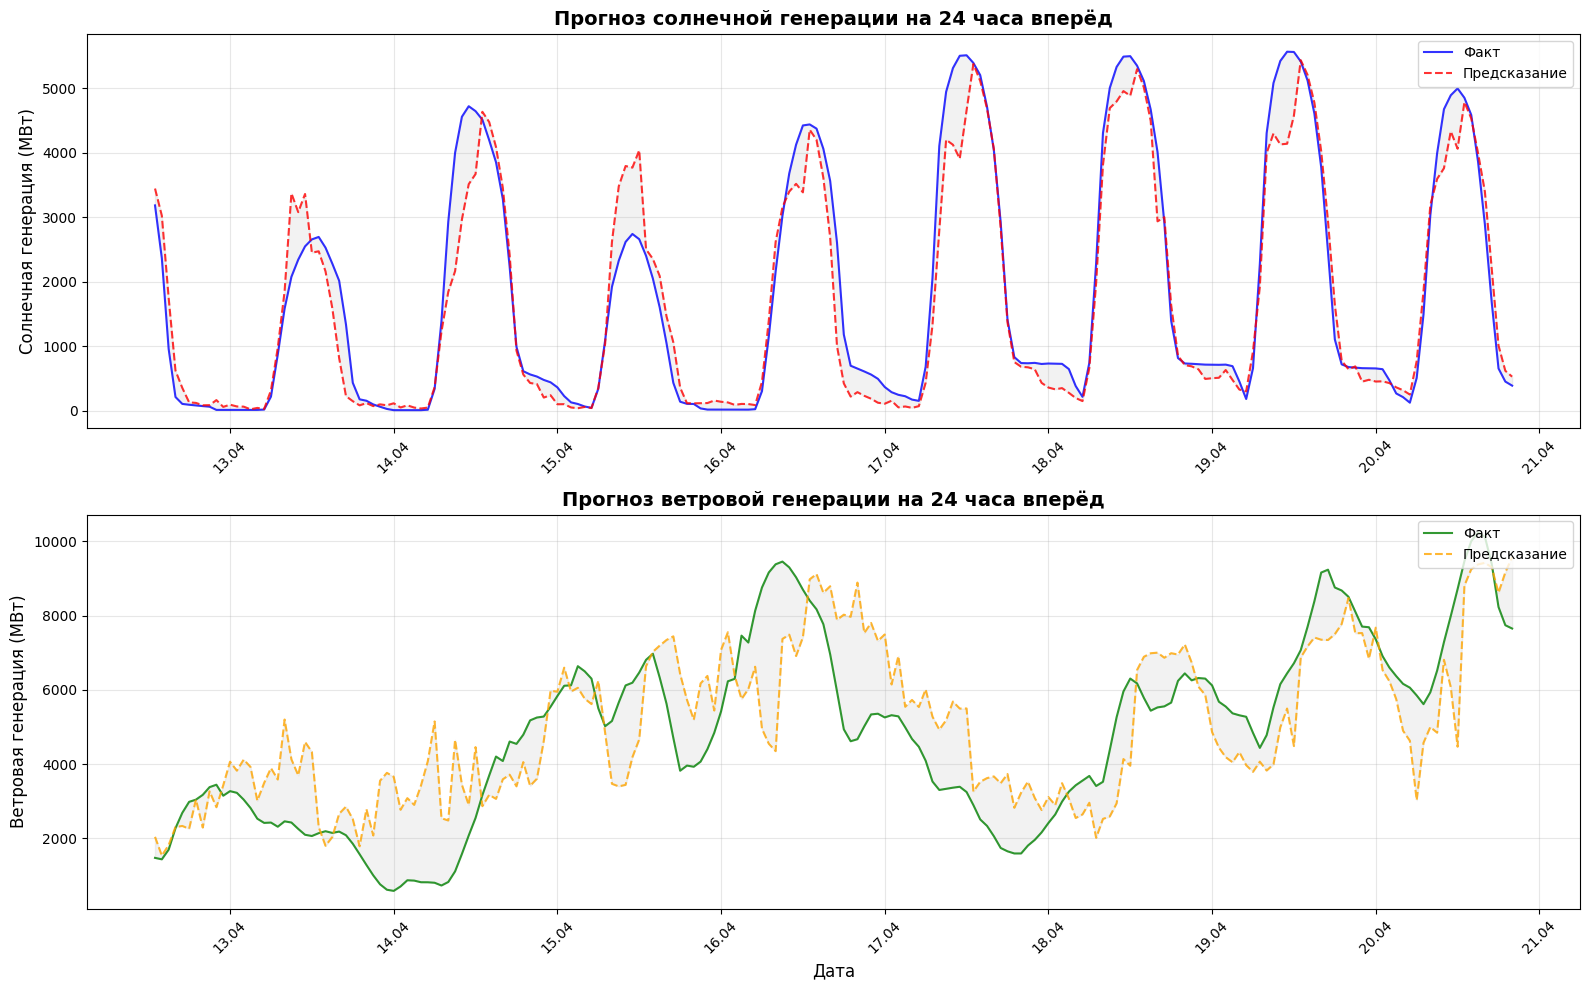


Метрики для отображаемых 200 точек:
Солнечная: RMSE=513 МВт, MAE=337 МВт, R²=0.922
Ветровая:  RMSE=1634 МВт, MAE=1330 МВт, R²=0.545


In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Собираем предсказания для первых 200 тестовых точек
test_times = []
test_true_solar = []
test_pred_solar = []
test_true_wind = []
test_pred_wind = []

for base_idx in test_12[:9]:  # 9 точек 12:00 дадут 9*24=216 прогнозов, берём с запасом
    base_time = df_clean.loc[base_idx, 'time']
    for h in range(1, 25):
        target_time = base_time + pd.Timedelta(hours=h)
        
        p_s = predictions_solar.get((target_time, h))
        p_w = predictions_wind.get((target_time, h))
        
        if p_s is None or p_w is None:
            continue
            
        test_times.append(target_time)
        test_true_solar.append(df_clean[df_clean['time'] == target_time]['generation solar'].values[0])
        test_pred_solar.append(p_s)
        test_true_wind.append(df_clean[df_clean['time'] == target_time]['generation wind onshore'].values[0])
        test_pred_wind.append(p_w)

# Оставляем первые 200 точек
test_times = test_times[:200]
test_true_solar = test_true_solar[:200]
test_pred_solar = test_pred_solar[:200]
test_true_wind = test_true_wind[:200]
test_pred_wind = test_pred_wind[:200]

# Создаём график
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# График солнечной генерации
ax1.plot(test_times, test_true_solar, 'b-', label='Факт', linewidth=1.5, alpha=0.8)
ax1.plot(test_times, test_pred_solar, 'r--', label='Предсказание', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('Солнечная генерация (МВт)', fontsize=12)
ax1.set_title('Прогноз солнечной генерации на 24 часа вперёд', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.fill_between(test_times, test_true_solar, test_pred_solar, alpha=0.1, color='gray')

# График ветровой генерации
ax2.plot(test_times, test_true_wind, 'g-', label='Факт', linewidth=1.5, alpha=0.8)
ax2.plot(test_times, test_pred_wind, 'orange', linestyle='--', label='Предсказание', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Ветровая генерация (МВт)', fontsize=12)
ax2.set_xlabel('Дата', fontsize=12)
ax2.set_title('Прогноз ветровой генерации на 24 часа вперёд', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.fill_between(test_times, test_true_wind, test_pred_wind, alpha=0.1, color='gray')

# Форматирование оси времени
for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Дополнительно: метрики для этих 200 точек
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rmse_s = np.sqrt(mean_squared_error(test_true_solar, test_pred_solar))
mae_s = mean_absolute_error(test_true_solar, test_pred_solar)
r2_s = r2_score(test_true_solar, test_pred_solar)

rmse_w = np.sqrt(mean_squared_error(test_true_wind, test_pred_wind))
mae_w = mean_absolute_error(test_true_wind, test_pred_wind)
r2_w = r2_score(test_true_wind, test_pred_wind)

print(f"\nМетрики для отображаемых 200 точек:")
print(f"Солнечная: RMSE={rmse_s:.0f} МВт, MAE={mae_s:.0f} МВт, R²={r2_s:.3f}")
print(f"Ветровая:  RMSE={rmse_w:.0f} МВт, MAE={mae_w:.0f} МВт, R²={r2_w:.3f}")

## Модель Prophet

### Солнечные станции

#### Подготовка данных для Prophet

Prophet требует столбцы ds (время) и y (целевая переменная).

In [40]:
df_prophet_solar = df[['time', 'generation solar', 
                        'temp', 'clouds_all_Valencia', 'humidity_Valencia',
                        'hour']].copy()

df_prophet_solar.columns = ['ds', 'y', 'temp', 'clouds', 'humidity', 'hour']

# Лаги выработки
df_prophet_solar['y_lag_24'] = df_prophet_solar['y'].shift(24)
df_prophet_solar['y_lag_48'] = df_prophet_solar['y'].shift(48)
df_prophet_solar['y_lag_168'] = df_prophet_solar['y'].shift(168)

# Будущая погода, ближайшие важные точки
df_prophet_solar['temp_tomorrow'] = df_prophet_solar['temp'].shift(-24)
df_prophet_solar['clouds_tomorrow'] = df_prophet_solar['clouds'].shift(-24)

df_prophet_solar = df_prophet_solar.dropna()

# Разделение
split_idx = int(len(df_prophet_solar) * 0.82)
train_solar = df_prophet_solar.iloc[:split_idx]
test_solar = df_prophet_solar.iloc[split_idx:]

print(f"Solar: {len(df_prophet_solar)} строк, {len(df_prophet_solar.columns)-2} признаков")
print(f"Train: {len(train_solar)} | Test: {len(test_solar)}")

Solar: 34854 строк, 9 признаков
Train: 28580 | Test: 6274


#### Модель и применение

In [41]:
regressors_solar = ['temp', 'clouds', 'humidity', 'hour',
                    'y_lag_24', 'y_lag_48', 'y_lag_168',
                    'temp_tomorrow', 'clouds_tomorrow']

model_solar = Prophet(
    yearly_seasonality='auto',
    weekly_seasonality='auto',
    daily_seasonality='auto',
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=15.0,
    seasonality_mode='additive',
    interval_width=0.80
)

for reg in regressors_solar:
    model_solar.add_regressor(reg)

model_solar.fit(train_solar)

# Прогноз
future_solar = test_solar[['ds'] + regressors_solar]
forecast_solar = model_solar.predict(future_solar)

y_true_s = test_solar['y'].values
y_pred_s = forecast_solar['yhat'].values

# Метрики
rmse_s = np.sqrt(mean_squared_error(y_true_s, y_pred_s))
mae_s = mean_absolute_error(y_true_s, y_pred_s)
r2_s = r2_score(y_true_s, y_pred_s)
wape_s = np.sum(np.abs(y_true_s - y_pred_s)) / np.sum(np.abs(y_true_s)) * 100

print("PROPHET SOLAR")
print(f"RMSE: {rmse_s:.0f} МВт | MAE: {mae_s:.0f} МВт | R²: {r2_s:.3f} | WAPE: {wape_s:.1f}%")

16:39:57 - cmdstanpy - INFO - Chain [1] start processing
16:40:04 - cmdstanpy - INFO - Chain [1] done processing


PROPHET SOLAR
RMSE: 727 МВт | MAE: 471 МВт | R²: 0.815 | WAPE: 32.9%


#### График

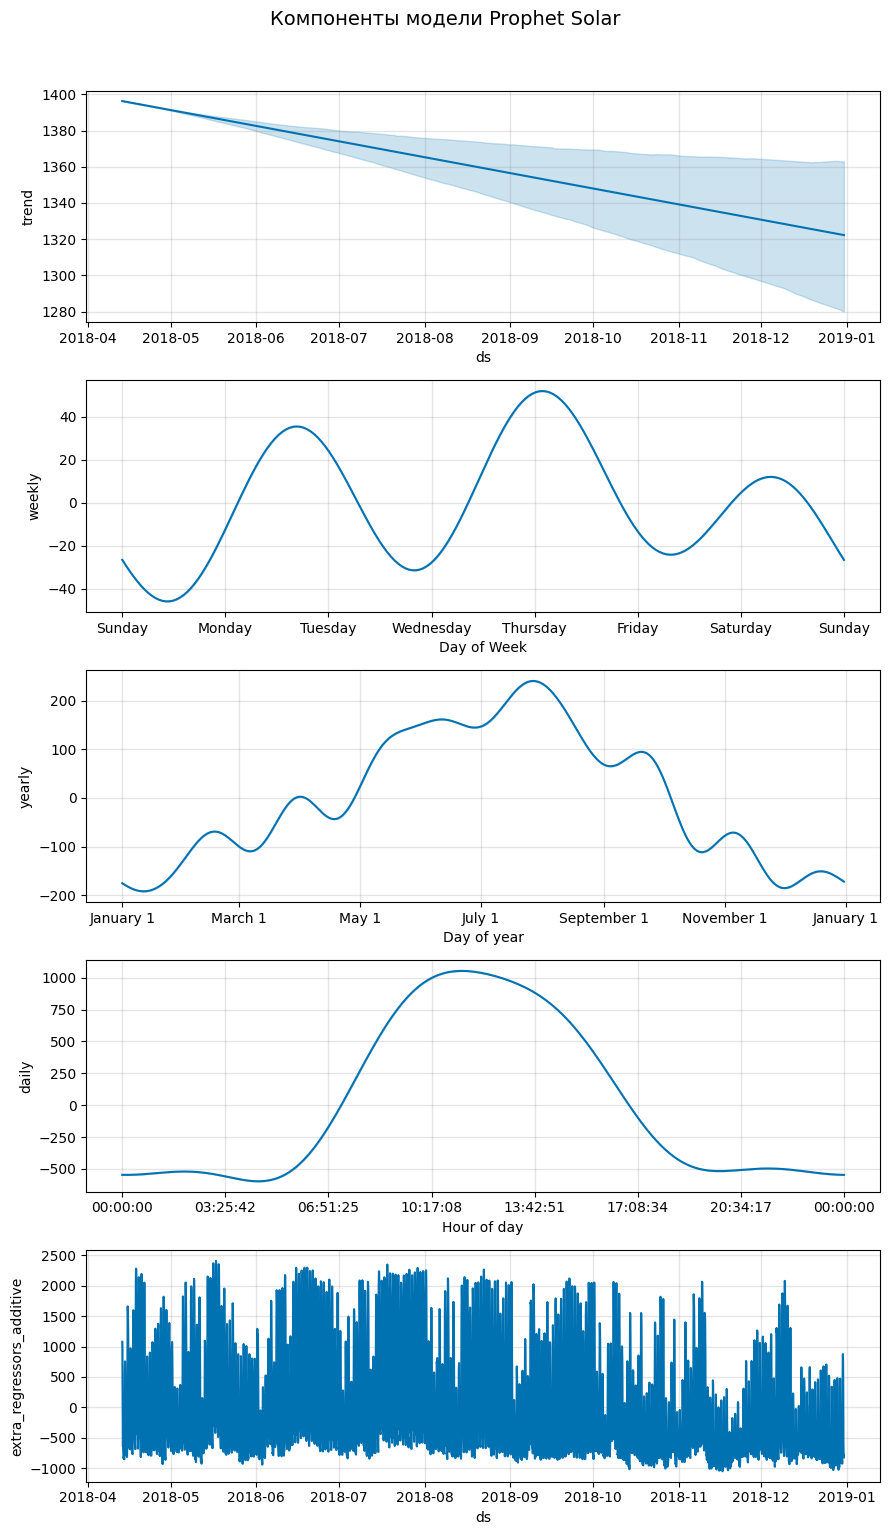

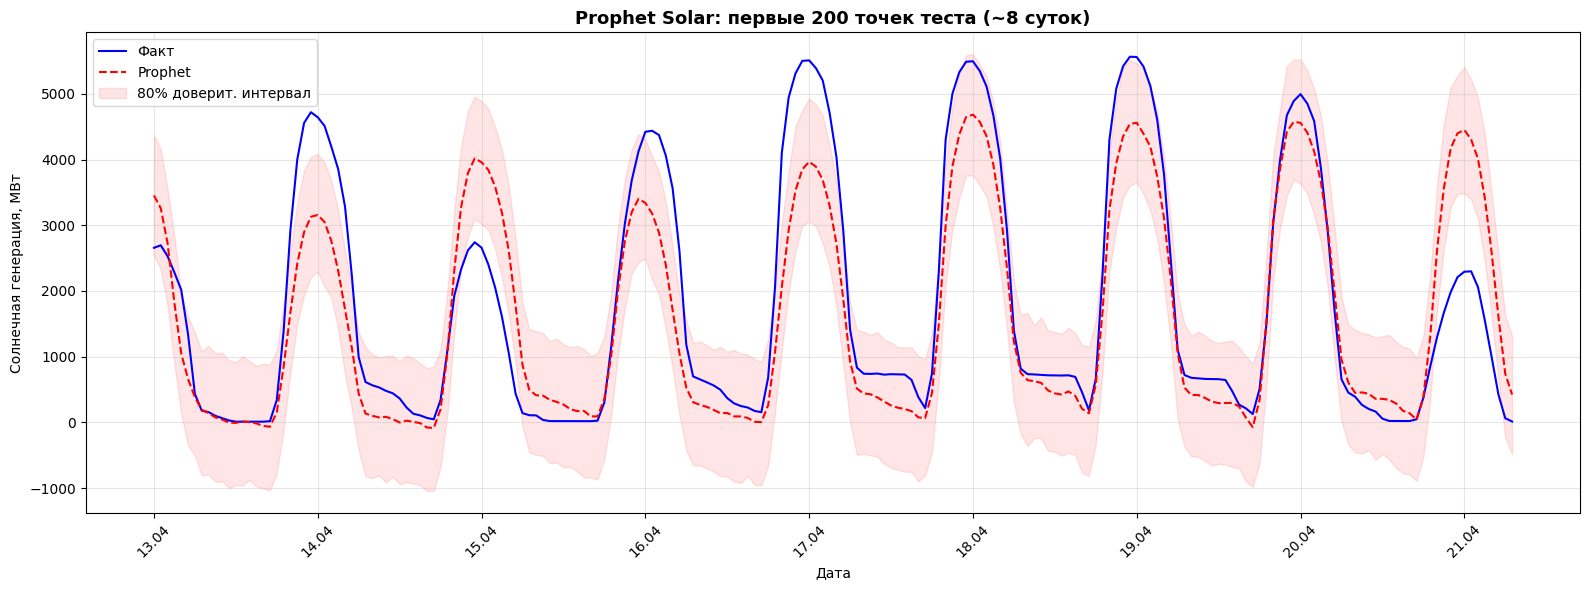

Solar (200 точек): R²=0.781, MAE=624 МВт


In [ ]:
# Компоненты модели
fig_comp = model_solar.plot_components(forecast_solar)
plt.suptitle('Компоненты модели Prophet Solar', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# 200 точек теста
n = 200
plt.figure(figsize=(16, 6))
plt.plot(range(n), y_true_s[:n], 'b-', label='Факт', linewidth=1.5)
plt.plot(range(n), y_pred_s[:n], 'r--', label='Prophet', linewidth=1.5)
plt.fill_between(range(n), 
                 forecast_solar['yhat_lower'].values[:n],
                 forecast_solar['yhat_upper'].values[:n],
                 alpha=0.1, color='red', label='80% доверит. интервал')

# Подписи дат
tick_pos = range(0, n, 24)
tick_lab = [test_solar['ds'].iloc[i].strftime('%d.%m') for i in tick_pos]
plt.xticks(tick_pos, tick_lab, rotation=45)

plt.xlabel('Дата')
plt.ylabel('Солнечная генерация, МВт')
plt.title(f'Прогноз солнечной генерации (Prophet)', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

r2_200 = r2_score(y_true_s[:n], y_pred_s[:n])
mae_200 = mean_absolute_error(y_true_s[:n], y_pred_s[:n])
print(f"Solar ({n} точек): R²={r2_200:.3f}, MAE={mae_200:.0f} МВт")

### Ветер

#### Подготовка данных

In [45]:
df_prophet_wind = df[['time', 'generation wind onshore',
                       'wind_speed_Valencia', 'wind_speed_Madrid', 'wind_speed_Bilbao',
                       'wind_deg_Valencia', 'pressure_Valencia',
                       'hour']].copy()

df_prophet_wind.columns = ['ds', 'y', 'wind_val', 'wind_mad', 'wind_bil',
                           'wind_deg_val', 'pressure', 'hour']

df_prophet_wind['y_lag_24'] = df_prophet_wind['y'].shift(24)
df_prophet_wind['y_lag_48'] = df_prophet_wind['y'].shift(48)

df_prophet_wind['wind_deg_val_tomorrow'] = df_prophet_wind['wind_deg_val'].shift(-24)
df_prophet_wind['pressure_tomorrow'] = df_prophet_wind['pressure'].shift(-24)

df_prophet_wind = df_prophet_wind.dropna()

split_idx_w = int(len(df_prophet_wind) * 0.80)
train_wind = df_prophet_wind.iloc[:split_idx_w]
test_wind = df_prophet_wind.iloc[split_idx_w:]


print(f"Wind: {len(df_prophet_wind)} строк, {len(df_prophet_wind.columns)-2} признаков")

Wind: 34974 строк, 10 признаков


#### Модель и применение

In [49]:
model_wind = Prophet(
    yearly_seasonality='auto',
    weekly_seasonality='auto',
    daily_seasonality='auto',
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=5.0,
    seasonality_mode='multiplicative',
    interval_width=0.80
)

regressors_wind = ['wind_val', 'wind_mad', 'wind_bil',
                   'hour','y_lag_24', 'y_lag_48',
                   'wind_deg_val_tomorrow', 'pressure_tomorrow']

for reg in regressors_wind:
    model_wind.add_regressor(reg)

model_wind.fit(train_wind)

# Прогноз
future_wind = test_wind[['ds'] + regressors_wind]
forecast_wind = model_wind.predict(future_wind)

y_true_w = test_wind['y'].values
y_pred_w = forecast_wind['yhat'].values

# Метрики
rmse_w = np.sqrt(mean_squared_error(y_true_w, y_pred_w))
mae_w = mean_absolute_error(y_true_w, y_pred_w)
r2_w = r2_score(y_true_w, y_pred_w)
wape_w = np.sum(np.abs(y_true_w - y_pred_w)) / np.sum(np.abs(y_true_w)) * 100

print("_" * 50)
print("PROPHET WIND")
print(f"RMSE: {rmse_w:.0f} МВт | MAE: {mae_w:.0f} МВт | R²: {r2_w:.3f} | WAPE: {wape_w:.1f}%")

16:43:29 - cmdstanpy - INFO - Chain [1] start processing
16:43:33 - cmdstanpy - INFO - Chain [1] done processing


__________________________________________________
PROPHET WIND
RMSE: 2675 МВт | MAE: 2180 МВт | R²: 0.311 | WAPE: 40.8%


#### Визуализация результата

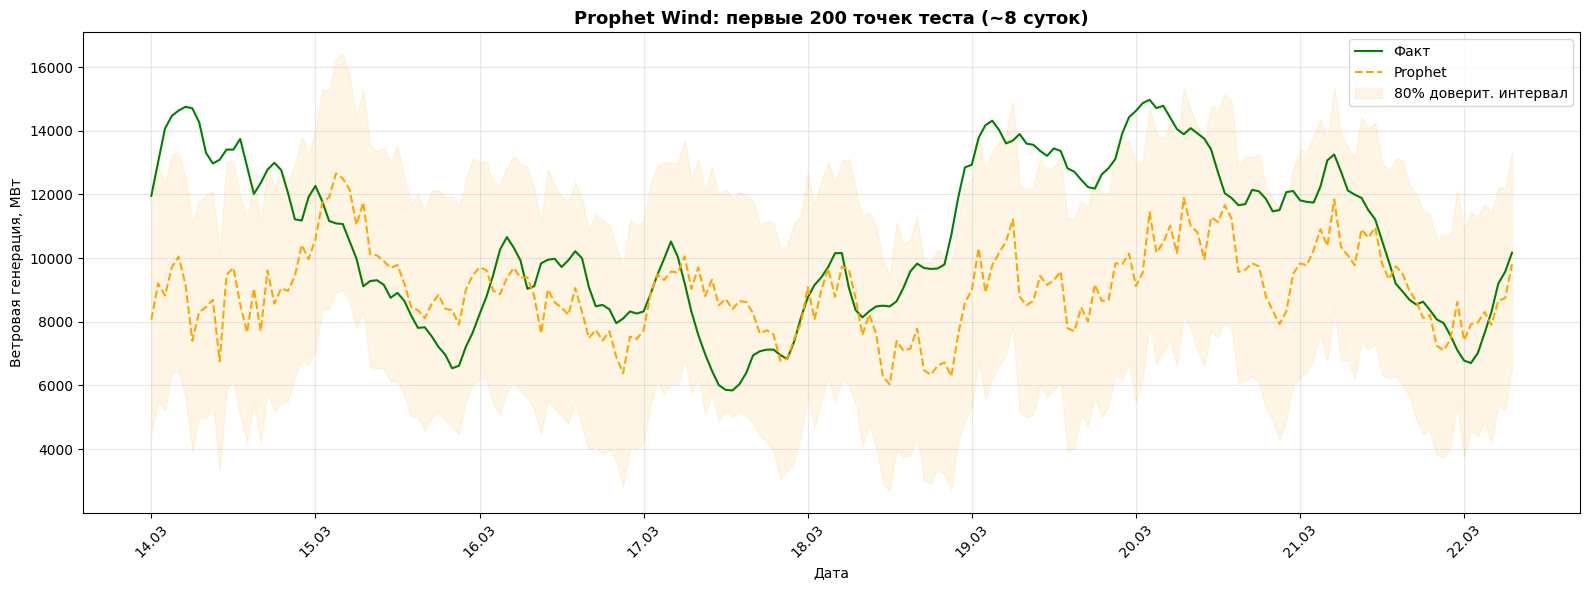

       Модель RMSE (МВт) MAE (МВт)    R² WAPE (%)
Prophet Solar        727       471 0.815     32.9
 Prophet Wind       2675      2180 0.311     40.8


In [ ]:
n_w = 200
plt.figure(figsize=(16, 6))
plt.plot(range(n_w), y_true_w[:n_w], 'g-', label='Факт', linewidth=1.5)
plt.plot(range(n_w), y_pred_w[:n_w], 'orange', linestyle='--', label='Prophet', linewidth=1.5)
plt.fill_between(range(n_w),
                 forecast_wind['yhat_lower'].values[:n_w],
                 forecast_wind['yhat_upper'].values[:n_w],
                 alpha=0.1, color='orange', label='80% доверит. интервал')

tick_pos_w = range(0, n_w, 24)
tick_lab_w = [test_wind['ds'].iloc[i].strftime('%d.%m') for i in tick_pos_w]
plt.xticks(tick_pos_w, tick_lab_w, rotation=45)

plt.xlabel('Дата')
plt.ylabel('Ветровая генерация, МВт')
plt.title(f'Прогноз ветровой генерации (Prophet)', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Сводка
results = pd.DataFrame({
    'Модель': ['Prophet Solar', 'Prophet Wind'],
    'RMSE (МВт)': [f'{rmse_s:.0f}', f'{rmse_w:.0f}'],
    'MAE (МВт)': [f'{mae_s:.0f}', f'{mae_w:.0f}'],
    'R²': [f'{r2_s:.3f}', f'{r2_w:.3f}'],
    'WAPE (%)': [f'{wape_s:.1f}', f'{wape_w:.1f}']
})


print(results.to_string(index=False))

### Встроенные графики

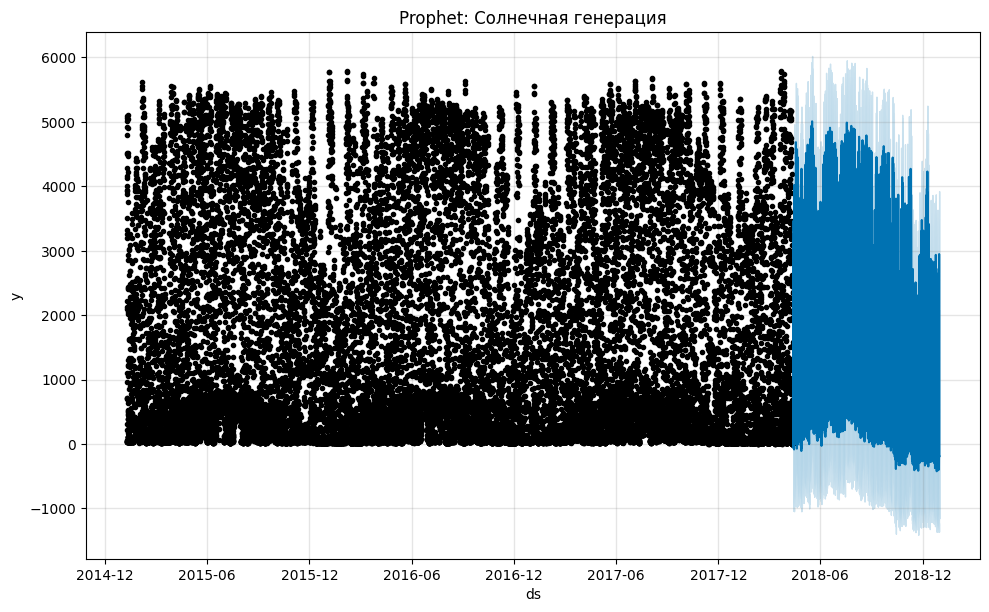

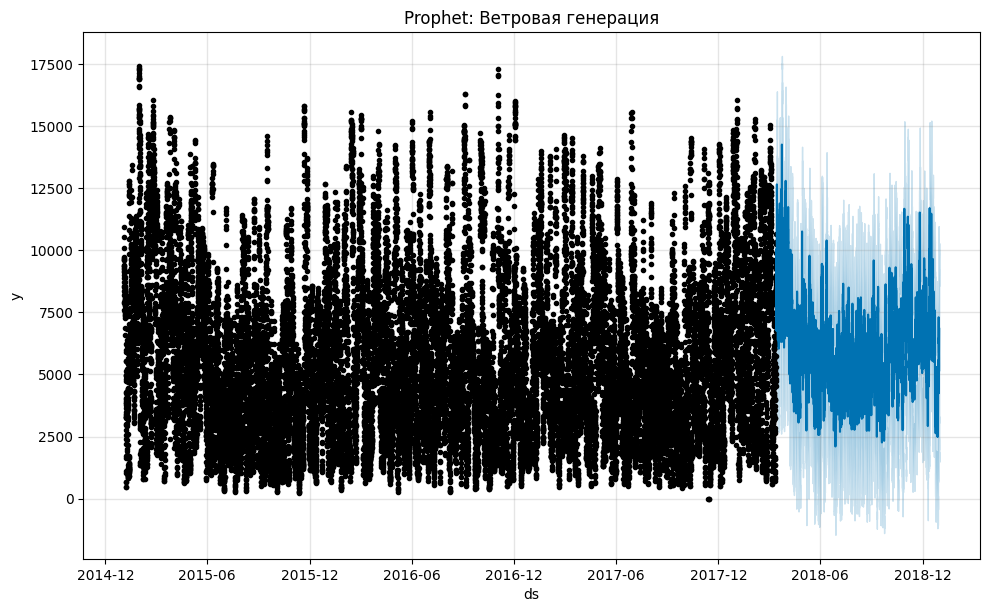

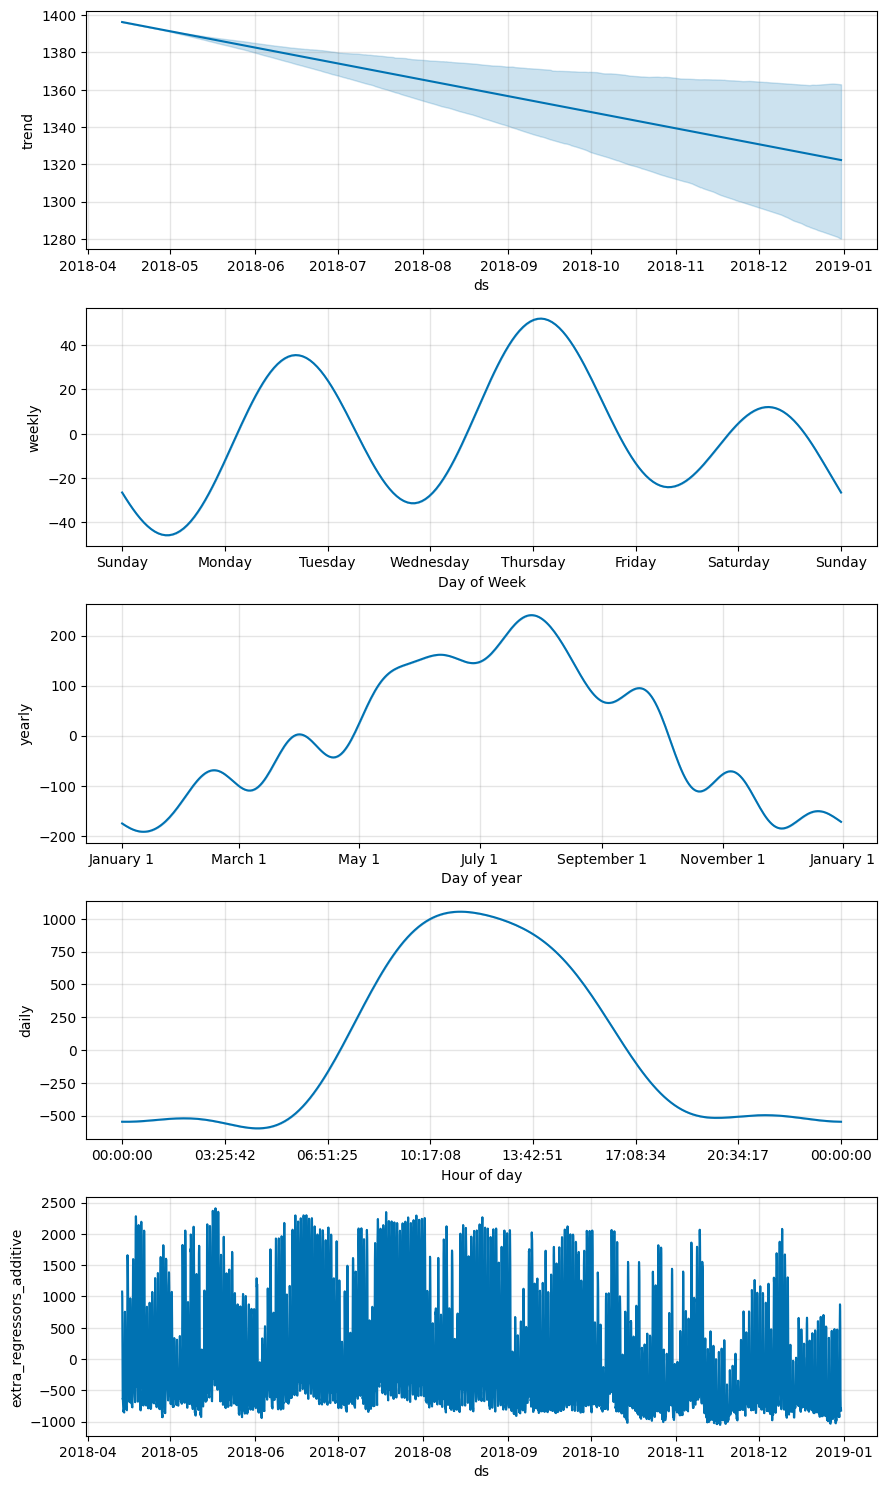

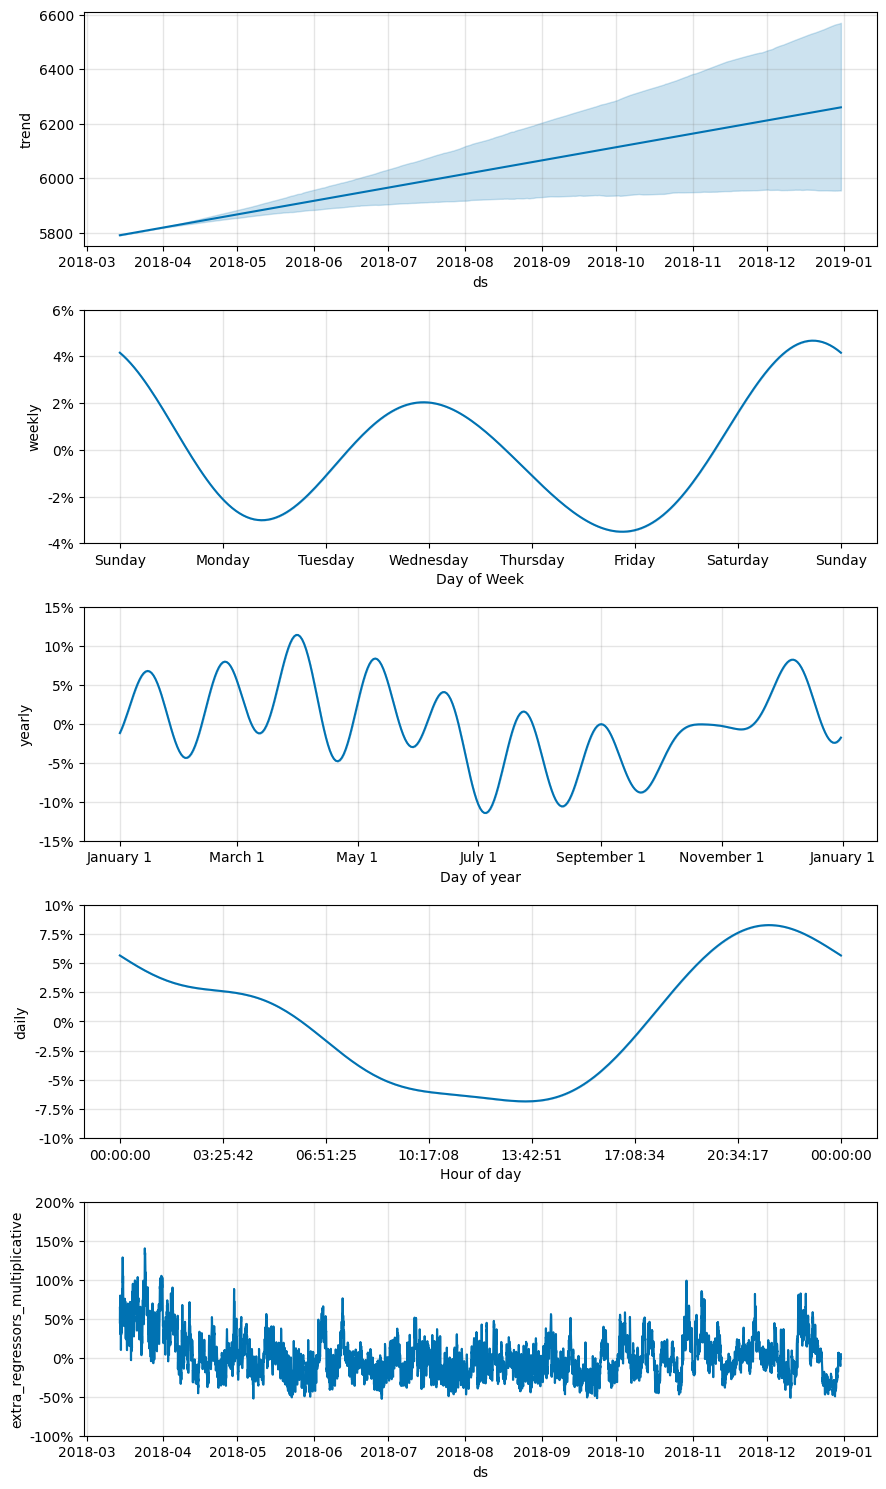

In [48]:
# График Prophet со встроенной визуализацией
fig1 = model_solar.plot(forecast_solar)
plt.title('Prophet: Солнечная генерация')
plt.show()

fig2 = model_wind.plot(forecast_wind)
plt.title('Prophet: Ветровая генерация')
plt.show()

# Компоненты (тренд, сезонность)
fig3 = model_solar.plot_components(forecast_solar)
plt.show()

fig4 = model_wind.plot_components(forecast_wind)
plt.show()

## Запись данных в файлы CSV для дальнейшего использования

In [ ]:
# df_predictions.to_csv('predictions.csv', index=False)
# df.to_csv('weather_and_price.csv', index=False)

# print(df.info())
# print(df_predictions.info())

